# Modeling - Degroot and Friekin Johnsen

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D

ROOT = Path('..').resolve()
CLEAN = ROOT / 'cleaned_data'

INIT_ROOT = Path('../..').joinpath('..').resolve()
PAIR_DIR = INIT_ROOT / 'tests' / 'single_shot_tests' / 'data' / 'stance_converted'

PARAMS = {
    'stance_clip': (-1.0, 1.0),
    'lambda_grid': np.linspace(0.05, 0.95, 19),
    'rollout_horizon_cap': 20,
    'validation_horizon': 8,
}

PREDICTOR_PARAMS = {
    'basis_grid': ['linear', 'linear_abs', 'quadratic', 'quadratic_abs'],
    'ridge_alphas': [0.0, 0.1, 1.0, 10.0],
    'noise_bins': 6,
    'rng_seed': 0,
}

USE_PREDICTED_INIT_WHEN_NO_SLICE0_SELF_POST = True

RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])
print('Project root:', ROOT)
print('Cleaned data:', CLEAN)
print('Runs found:', len(RUN_DIRS))
print('Rollout horizon cap:', PARAMS['rollout_horizon_cap'])
print('Pair dir:', PAIR_DIR)
for r in RUN_DIRS[:26]:
    print(' ', r.name)

Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Cleaned data: /Users/samuelli/Documents/code/llm/llm-network/modeling/cleaned_data
Runs found: 67
Rollout horizon cap: 20
Pair dir: /Users/samuelli/Documents/code/llm/tests/single_shot_tests/data/stance_converted
  run_20260320-130058
  run_20260320-133304
  run_20260320-140500
  run_20260320-143643
  run_20260320-150827
  run_20260320-154019
  run_20260320-161210
  run_20260320-164400
  run_20260320-171544
  run_20260320-174722
  run_20260321-121900
  run_20260321-125108
  run_20260321-132251
  run_20260321-135440
  run_20260321-142622
  run_20260321-145803
  run_20260321-152938
  run_20260321-160106
  run_20260321-163235
  run_20260321-170416
  run_20260322-212540
  run_20260324-095805
  run_20260324-115915
  run_20260324-135956
  run_20260324-160041
  run_20260326-014533


## Data Construction

- Per-run, per-agent stance trajectory is represented as $x_i^{(r)}(t)$.
- Initialization uses run-derived signals and global fallback priors from observed runs.
- Each run is mapped onto a shared global agent index.
- Neighbor sets are built per run from that run's graph: $\mathcal{N}^{(r)}_i$.

In [2]:
from data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
# print (GLOBAL_INIT_BY_AGENT)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(d, GLOBAL_AGENT_IDS, target_agent_fraction=0.4, return_post_mask=True, constrain_messages=150)
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agent count:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for rn in sorted(RUN_TRAJ.keys()):
    tr = RUN_TRAJ[rn]
    print(f"{rn}: trajectory shape={tr.shape}, horizon={tr.shape[0] - 1}")

Global agent count: 30
Global init priors available: 30
run_20260320-130058: trajectory shape=(9, 30), horizon=8
run_20260320-133304: trajectory shape=(12, 30), horizon=11
run_20260320-140500: trajectory shape=(9, 30), horizon=8
run_20260320-143643: trajectory shape=(9, 30), horizon=8
run_20260320-150827: trajectory shape=(9, 30), horizon=8
run_20260320-154019: trajectory shape=(11, 30), horizon=10
run_20260320-161210: trajectory shape=(9, 30), horizon=8
run_20260320-164400: trajectory shape=(11, 30), horizon=10
run_20260320-171544: trajectory shape=(9, 30), horizon=8
run_20260320-174722: trajectory shape=(10, 30), horizon=9
run_20260321-121900: trajectory shape=(11, 30), horizon=10
run_20260321-125108: trajectory shape=(10, 30), horizon=9
run_20260321-132251: trajectory shape=(8, 30), horizon=7
run_20260321-135440: trajectory shape=(12, 30), horizon=11
run_20260321-142622: trajectory shape=(10, 30), horizon=9
run_20260321-145803: trajectory shape=(10, 30), horizon=9
run_20260321-15293

In [3]:
# RUN_TRAJ posting audit: use post mask to separate true posts from feed-forward values.
print('RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)')
print('N =', N)
all_post_fracs = []
for rn in sorted(RUN_TRAJ.keys()):
    tr = np.asarray(RUN_TRAJ[rn], dtype=float)
    pm = np.asarray(RUN_POST_MASK[rn], dtype=bool)
    per_slice_post_frac = pm.mean(axis=1)
    all_post_fracs.extend(per_slice_post_frac.tolist())
    print(f"{rn}: post_mean={np.mean(per_slice_post_frac):.3f}, post_min={np.min(per_slice_post_frac):.3f}, post_max={np.max(per_slice_post_frac):.3f}, slices={tr.shape[0]}")

if all_post_fracs:
    print('\nGlobal RUN_TRAJ post-rate summary:')
    print(f"mean={np.mean(all_post_fracs):.3f}, median={np.median(all_post_fracs):.3f}, min={np.min(all_post_fracs):.3f}, max={np.max(all_post_fracs):.3f}, total_slices={len(all_post_fracs)}")


RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)
N = 30
run_20260320-130058: post_mean=0.256, post_min=0.100, post_max=0.367, slices=9
run_20260320-133304: post_mean=0.244, post_min=0.167, post_max=0.367, slices=12
run_20260320-140500: post_mean=0.341, post_min=0.233, post_max=0.433, slices=9
run_20260320-143643: post_mean=0.267, post_min=0.100, post_max=0.367, slices=9
run_20260320-150827: post_mean=0.289, post_min=0.233, post_max=0.367, slices=9
run_20260320-154019: post_mean=0.267, post_min=0.100, post_max=0.400, slices=11
run_20260320-161210: post_mean=0.278, post_min=0.133, post_max=0.367, slices=9
run_20260320-164400: post_mean=0.255, post_min=0.067, post_max=0.433, slices=11
run_20260320-171544: post_mean=0.326, post_min=0.233, post_max=0.400, slices=9
run_20260320-174722: post_mean=0.253, post_min=0.133, post_max=0.367, slices=10
run_20260321-121900: post_mean=0.248, post_min=0.200, post_max=0.333, slices=11
run_20260321-125108: post_mean=0.290, post_min=

In [4]:
def build_dataset_from_run(run):
    X = []
    Y = []
    for t in range(len(run) - 1):
        X.append(run[t])
        Y.append(run[t + 1])
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    return X, Y

## DeGroot - Predict

In [5]:
import cvxpy as cp

def fit_row_stochastic_W_from_pooled_runs(run_traj_map, run_neighbors):
    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    for run_name in run_names[1:]:
        if run_neighbors[run_name] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')

    X_blocks = []
    Y_blocks = []
    for run_name in run_names:
        X, Y = build_dataset_from_run(np.asarray(run_traj_map[run_name], dtype=float))
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)

    n = X_pool.shape[1]
    W = np.zeros((n, n), dtype=float)

    for i in range(n):
        ns = ref_neighbors[i]
        X_ns = X_pool[:, ns]
        y = Y_pool[:, i]

        w_ns = cp.Variable(len(ns))
        objective = cp.Minimize(cp.sum_squares(X_ns @ w_ns - y))
        constraints = [w_ns >= 0, cp.sum(w_ns) == 1]
        problem = cp.Problem(objective, constraints)
        problem.solve()

        row = np.zeros(n, dtype=float)
        row[ns] = np.asarray(w_ns.value, dtype=float).ravel()
        W[i] = row

    return W, X_pool, Y_pool

In [6]:
GLOBAL_W, X_pool, Y_pool = fit_row_stochastic_W_from_pooled_runs(RUN_TRAJ, RUN_NEIGHBORS)

print('Min entry:', float(GLOBAL_W.min()), 'Max entry:', float(GLOBAL_W.max()))
print("Global MSE loss:", float(np.mean((Y_pool - X_pool @ GLOBAL_W.T) ** 2)))
print('DeGroot W eigenvalues:', np.linalg.eigvals(GLOBAL_W))
print('DeGroot W spectral radius:', float(np.max(np.abs(np.linalg.eigvals(GLOBAL_W)))))

Min entry: -1.0404586371125109e-16 Max entry: 0.6485512335568137
Global MSE loss: 0.025754995811714417
DeGroot W eigenvalues: [ 1.00000000e+00+0.j          7.59932612e-01+0.j
  7.04234398e-01+0.0036442j   7.04234398e-01-0.0036442j
  5.50440830e-01+0.j         -6.75082715e-01+0.j
 -6.56797707e-01+0.j          3.69084887e-01+0.j
 -5.04544239e-01+0.j          2.54488016e-01+0.j
 -4.34491572e-01+0.j          1.60994608e-01+0.j
  1.16930392e-01+0.12082772j  1.16930392e-01-0.12082772j
 -3.61514772e-01+0.j         -3.02676994e-01+0.07473799j
 -3.02676994e-01-0.07473799j -1.77918480e-01+0.11953562j
 -1.77918480e-01-0.11953562j -2.49239172e-01+0.j
 -2.41049122e-01+0.02715337j -2.41049122e-01-0.02715337j
 -4.23714196e-02+0.11068072j -4.23714196e-02-0.11068072j
 -1.41895957e-01+0.05980142j -1.41895957e-01-0.05980142j
  3.48482656e-02+0.j         -6.26782338e-02+0.j
  8.44751911e-04+0.j         -1.67911939e-02+0.j        ]
DeGroot W spectral radius: 1.0


In [7]:
print (GLOBAL_W[0])

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -3.76023000e-17 -5.40834931e-17  1.36638160e-01  0.00000000e+00
  0.00000000e+00  0.00000000e+00  2.56256507e-01 -2.70631359e-17
  0.00000000e+00  3.03784278e-01  6.66887693e-02  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  2.36632286e-01  0.00000000e+00]


In [8]:
def degroot_rollout_prediction(W, x0, horizon):
    predictions = [x0]
    current_x = x0.copy()
    for t in range(horizon):
        current_x = W @ current_x
        predictions.append(current_x.copy())
    return predictions
    
PREDICTED_TRAJ = {rn: degroot_rollout_prediction(GLOBAL_W, tr[0], PARAMS['rollout_horizon_cap']) for rn, tr in RUN_TRAJ.items()}

run_20260326-034648


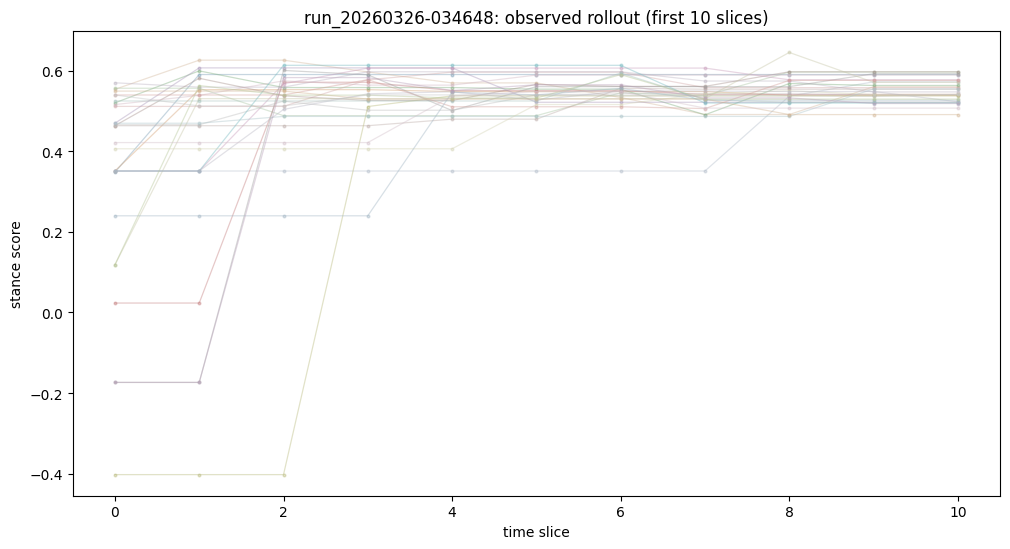

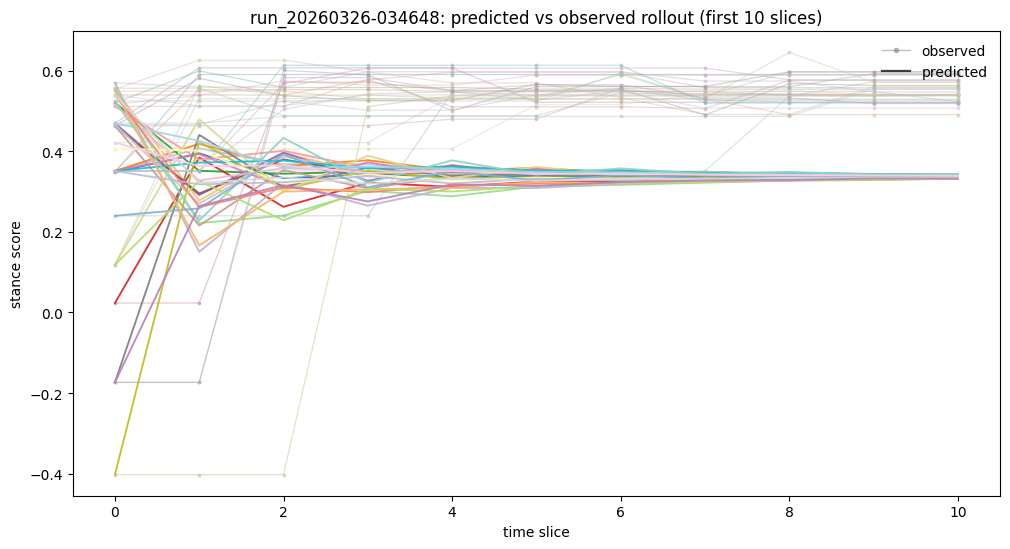

Steady-state mean (observed): 0.5501194172849257
Steady-state mean (predicted): 0.33790637481817276
Steady-state variance (observed): 0.0009174227545565929
Steady-state variance (predicted): 2.5362501930090304e-05
Wasserstein distance: 0.1821


In [9]:
# Mean, Variance, Wasserstein helpers
from plot_utils import plot_observed_trajectories, plot_predicted_vs_observed, calculate_mean_and_variance, compute_wasserstein_distance
run_names = sorted(RUN_TRAJ.keys())

print (run_names[26])

plot_observed_trajectories(run_names[26], RUN_TRAJ[run_names[26]], GLOBAL_AGENT_IDS, 20)
plot_predicted_vs_observed(run_names[26], RUN_TRAJ[run_names[26]], PREDICTED_TRAJ[run_names[26]], GLOBAL_AGENT_IDS, 20)

T = min(np.asarray(RUN_TRAJ[run_names[26]]).shape[0], np.asarray(PREDICTED_TRAJ[run_names[26]]).shape[0])
obs = RUN_TRAJ[run_names[26]][:T]
pred = PREDICTED_TRAJ[run_names[26]][:T]

mean_var_metrics = calculate_mean_and_variance(obs, pred, last_n=3)
print(f"Steady-state mean (observed): {mean_var_metrics['steady_mean_obs']}")
print(f"Steady-state mean (predicted): {mean_var_metrics['steady_mean_pred']}")
print(f"Steady-state variance (observed): {mean_var_metrics['steady_var_obs']}")
print(f"Steady-state variance (predicted): {mean_var_metrics['steady_var_pred']}")

W_metric = compute_wasserstein_distance(obs, pred)
print(f"Wasserstein distance: {W_metric:.4f}")

In [10]:
print (X_pool)

[[0.58594107 0.54584526 0.42816955 ... 0.57051744 0.49968562 0.43171439]
 [0.58594107 0.54584526 0.42816955 ... 0.54976541 0.49968562 0.43171439]
 [0.59753174 0.54584526 0.42816955 ... 0.54976541 0.49968562 0.43171439]
 ...
 [0.52413213 0.57881336 0.55551698 ... 0.50363913 0.56506485 0.55361457]
 [0.56594848 0.57881336 0.51730784 ... 0.55128417 0.56506485 0.50356432]
 [0.56594848 0.57835899 0.51730784 ... 0.55128417 0.54656135 0.50356432]]


In [11]:
from plot_utils import compute_eigenvalue
result = compute_eigenvalue(X_pool, Y_pool)
print('full eigenvalues:', len(result['eigvals_full']))
print('gram full shape:', result['gram_full_shape'])
print(result['eigvals_full'])

full eigenvalues: 900
gram full shape: (900, 900)
[2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.86695046e+00 3.86695046e+00 3.86

## Friedkin Johnsen Model - Static Graph structure based

In [12]:
def build_x0_from_agent_inits(agent_inits, n):
    x0 = np.full((n,), np.nan, dtype=float)
    for aid, val in agent_inits.items():
        idx = int(aid.split('_', 1)[1]) - 1
        x0[idx] = float(val)
    if np.isnan(x0).any():
        missing = np.where(np.isnan(x0))[0].tolist()
        raise ValueError(f'missing init values for indices: {missing}')
    return x0

In [13]:
#friedkin johnsen setup

def fit_friedkin_johnsen(run_traj_map, run_neighbors, lambda1, lambda2, agent_inits):
    if lambda1 < 0 or lambda2 < 0 or lambda1 + lambda2 > 1:
        raise ValueError('lambda1 and lambda2 must be nonnegative and satisfy lambda1 + lambda2 <= 1')

    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    # Ensure same graph across runs
    for rn in run_names[1:]:
        if run_neighbors[rn] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs')
        

    # Build pooled dataset
    X_blocks, Y_blocks, X0_blocks = [], [], []
    for rn in run_names:
        traj = np.asarray(run_traj_map[rn], dtype=float)
        X, Y = build_dataset_from_run(traj)
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)
    n = X_pool.shape[1]
    alpha = 1.0 - lambda1 - lambda2

    b = cp.Variable()  # scalar global bias
    W_vars = []        # store per-row variables
    objective_terms = []
    constraints = []

    x0_init = build_x0_from_agent_inits(agent_inits, n)

    for i in range(n):
        ns = ref_neighbors[i]
        if len(ns) == 0:
            continue  # skip isolated nodes safely

        w_ns = cp.Variable(len(ns))
        W_vars.append((i, ns, w_ns))

        X_ns = X_pool[:, ns]
        y = Y_pool[:, i]
        x0i = float(x0_init[i])

        pred = lambda1 * x0i + lambda2 * b + alpha * (X_ns @ w_ns)
        objective_terms.append(cp.sum_squares(y - pred))

        constraints += [
            w_ns >= 0,
            cp.sum(w_ns) == 1,
        ]

    # bias constraint
    constraints += [b >= -1, b <= 1]

    objective = cp.Minimize(cp.sum(objective_terms))
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if b.value is None:
        raise RuntimeError('Solver failed')

    # ---- RECONSTRUCT W ----
    W = np.zeros((n, n), dtype=float)
    for (i, ns, w_ns) in W_vars:
        W[i, ns] = np.asarray(w_ns.value).ravel()

    return W, float(b.value), X_pool, Y_pool

In [14]:
def friedkin_johnsen_rollout_prediction(W, bias, x0, horizon, lambda1, lambda2):
    alpha = 1.0 - lambda1 - lambda2
    x0 = np.asarray(x0, dtype=float)
    current_x = x0.copy()
    predictions = [current_x.copy()]
    bias_vec = np.full_like(current_x, float(bias), dtype=float)

    for _ in range(horizon):
        current_x = lambda1 * x0 + lambda2 * bias_vec + alpha * (W @ current_x)
        predictions.append(current_x.copy())

    return predictions


def select_friedkin_johnsen_lambdas(run_traj_map, run_neighbors, lambda_grid, agent_inits):
    best_result = None
    all_results = []

    for lambda1 in lambda_grid:
        for lambda2 in lambda_grid:
            if lambda1 + lambda2 > 1:
                continue

            W_hat, b_hat, X_pool, Y_pool = fit_friedkin_johnsen(
                run_traj_map,
                run_neighbors,
                lambda1,
                lambda2,
                agent_inits,
            )

            n = X_pool.shape[1]
            x0 = build_x0_from_agent_inits(agent_inits, n)
            alpha = 1.0 - lambda1 - lambda2
            pred_pool = lambda1 * x0[None, :] + lambda2 * b_hat + alpha * (X_pool @ W_hat.T)
            mse_pool = float(np.mean((Y_pool - pred_pool) ** 2))

            result = {
                'lambda1': float(lambda1),
                'lambda2': float(lambda2),
                'mse_pool': mse_pool,
            }
            all_results.append(result)

            if best_result is None or mse_pool < best_result['mse_pool']:
                best_result = result

    return best_result, all_results

In [15]:
from plot_utils import plot_observed_trajectories, plot_predicted_vs_observed, calculate_mean_and_variance, compute_wasserstein_distance

best_fj_result, fj_lambda_search_results = select_friedkin_johnsen_lambdas(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    PARAMS['lambda_grid'],
    agent_inits=GLOBAL_INIT_BY_AGENT
)

FJ_LAMBDA1 = best_fj_result['lambda1']
FJ_LAMBDA2 = best_fj_result['lambda2']

print('Best Friedkin-Johnsen lambdas')
print('lambda1:', FJ_LAMBDA1)
print('lambda2:', FJ_LAMBDA2)
print('Best pooled transition MSE:', best_fj_result['mse_pool'])

Best Friedkin-Johnsen lambdas
lambda1: 0.05
lambda2: 0.25
Best pooled transition MSE: 0.025150295118683833


Friedkin-Johnsen fit
Bias term: 0.5210553000839118
Global MSE loss: 0.027261293202900112


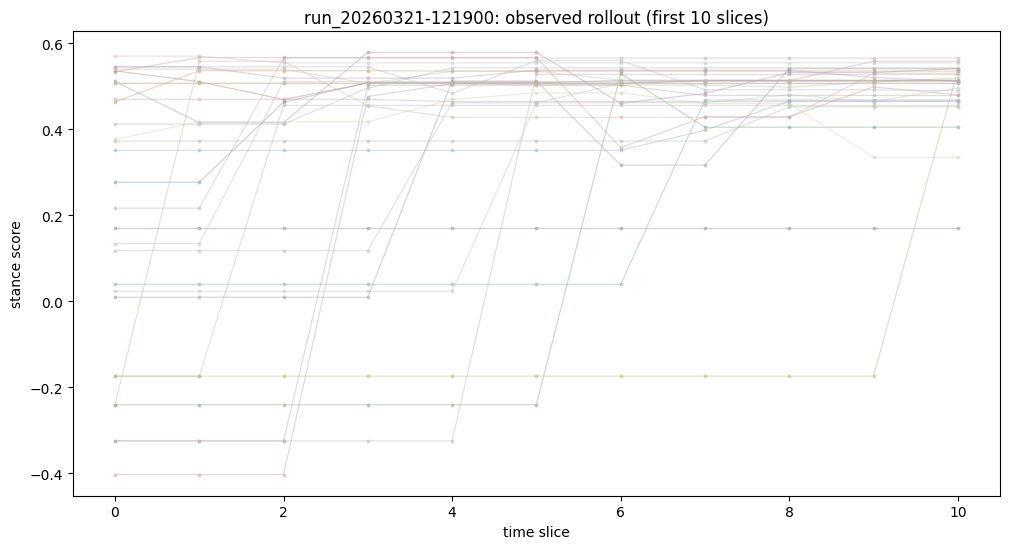

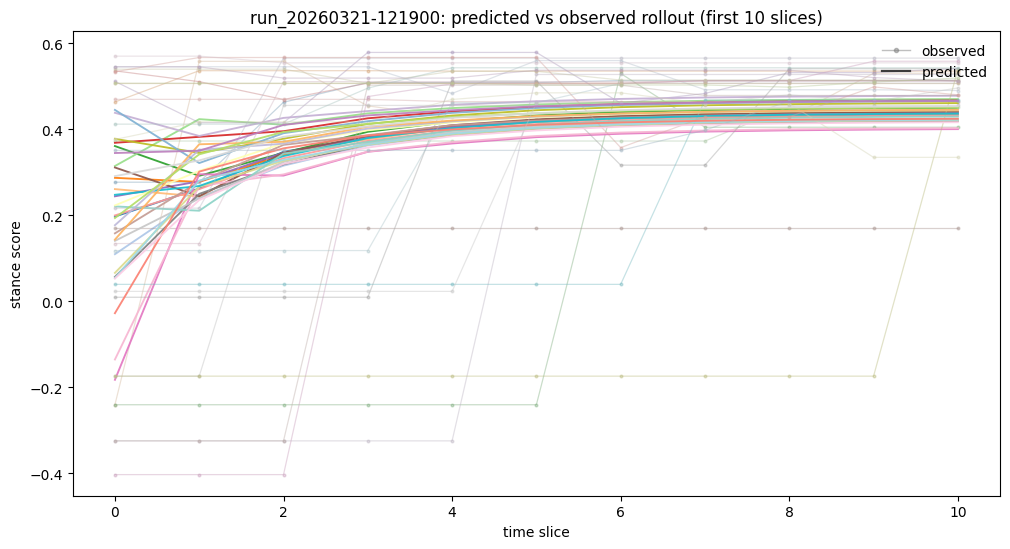

Average steady-state mean (observed): 0.4526355247768523
Average steady-state mean (predicted): 0.43205097070949405
Average steady-state variance (observed): 0.012182569717966543
Average steady-state variance (predicted): 0.000423195366356165
Average Wasserstein distance: 0.0963


In [16]:
FJ_LAMBDA1 = 0.1
FJ_LAMBDA2 = 0.3
FJ_W, FJ_b, X_pool_fj, Y_pool_fj = fit_friedkin_johnsen(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    FJ_LAMBDA1,
    FJ_LAMBDA2,
    GLOBAL_INIT_BY_AGENT
)

print('Friedkin-Johnsen fit')
print('Bias term:', FJ_b)
# print(FJ_W)
print('Global MSE loss:', float(np.mean((Y_pool_fj - X_pool_fj @ FJ_W.T) ** 2)))

PREDICTED_TRAJ_FJ = {
    rn: friedkin_johnsen_rollout_prediction(
        FJ_W,
        FJ_b,
        build_x0_from_agent_inits(GLOBAL_INIT_BY_AGENT, N),
        PARAMS['rollout_horizon_cap'],
        FJ_LAMBDA1,
        FJ_LAMBDA2,
    )
    for rn, tr in RUN_TRAJ.items()
}

run_names = sorted(RUN_TRAJ.keys())
run_id = run_names[10]

plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_FJ[run_id], GLOBAL_AGENT_IDS, 10)

per_run_metrics = []
per_run_wass = []

for rn in run_names:
    obs = np.asarray(RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PREDICTED_TRAJ_FJ[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]

    per_run_metrics.append(calculate_mean_and_variance(obs, pred, last_n=3))
    per_run_wass.append(compute_wasserstein_distance(obs, pred))

avg_mean_obs = float(np.mean([m['steady_mean_obs'] for m in per_run_metrics]))
avg_mean_pred = float(np.mean([m['steady_mean_pred'] for m in per_run_metrics]))
avg_var_obs = float(np.mean([m['steady_var_obs'] for m in per_run_metrics]))
avg_var_pred = float(np.mean([m['steady_var_pred'] for m in per_run_metrics]))
avg_wasserstein = float(np.mean(per_run_wass))

print(f"Average steady-state mean (observed): {avg_mean_obs}")
print(f"Average steady-state mean (predicted): {avg_mean_pred}")
print(f"Average steady-state variance (observed): {avg_var_obs}")
print(f"Average steady-state variance (predicted): {avg_var_pred}")
print(f"Average Wasserstein distance: {avg_wasserstein:.4f}")

In [17]:
from plot_utils import compute_fj_eigenvalue

fj_fixed_eig_result = compute_fj_eigenvalue(
    X_pool_fj,
    Y_pool_fj,
    lambda_1=FJ_LAMBDA1,
    lambda_2=FJ_LAMBDA2,
 )

print('FJ fixed eigenvalues:', len(fj_fixed_eig_result['eigvals_full']))
print('gram full shape:', fj_fixed_eig_result['gram_full_shape'])
print(fj_fixed_eig_result['eigvals_full'])

FJ fixed eigenvalues: 901
gram full shape: (901, 901)
[9.79685026e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 1.19873813e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.34610699e+00 1.39210217e+00 

## Friedkin Johnsen Joint Optimization

In [18]:
# Joint FJ fit with reparameterization: W_tilde = alpha * W, b_tilde = lambda2 * b

def fit_friedkin_johnsen_joint(run_traj_map, run_neighbors, agent_inits, eps=1e-4):
    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    for rn in run_names[1:]:
        if run_neighbors[rn] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')

    # Build pooled transitions with per-transition run-level initial condition x0.
    X_blocks = []
    Y_blocks = []

    for rn in run_names:
        traj = np.asarray(run_traj_map[rn], dtype=float)
        X, Y = build_dataset_from_run(traj)
        X_blocks.append(X)
        Y_blocks.append(Y)

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)
    _, n = X_pool.shape
    x0_init = build_x0_from_agent_inits(agent_inits, n)
    X0_pool = np.repeat(x0_init.reshape(1, -1), X_pool.shape[0], axis=0)
    # Decision variables.
    lambda1 = cp.Variable(nonneg=True)
    lambda2 = cp.Variable(nonneg=True)
    b_tilde = cp.Variable()  # equals lambda2 * b
    alpha = 1.0 - lambda1 - lambda2
    W_tilde = cp.Variable((n, n))

    # Least-squares objective on pooled transitions.
    ones_n = np.ones((n,), dtype=float)
    residual = Y_pool - (lambda1 * X0_pool + b_tilde * ones_n[None, :] + X_pool @ W_tilde.T)
    objective = cp.Minimize(cp.sum_squares(residual))
    constraints = []

    # Strict-like constraints via epsilon to support identifiability/bijection:
    # lambda1 + lambda2 < 1  ->  lambda1 + lambda2 <= 1 - eps
    # lambda2 != 0           ->  lambda2 >= eps
    constraints += [
        lambda2 >= eps,
        lambda1 >= 0.2,
        lambda1 + lambda2 <= 1.0 - eps,
        lambda1 <= 1.0,
    ]

    # Graph-structured nonnegative row constraints on W_tilde.
    for i in range(n):
        ns = ref_neighbors[i]
        allowed = np.zeros((n,), dtype=float)
        allowed[np.asarray(ns, dtype=int)] = 1.0

        constraints.append(W_tilde[i, :] >= 0)
        constraints.append(cp.sum(W_tilde[i, :]) == alpha)
        constraints.append(cp.multiply(1.0 - allowed, W_tilde[i, :]) == 0)

    # Since b in [-1, 1], b_tilde = lambda2 * b implies b_tilde in [-lambda2, lambda2].
    constraints += [
        b_tilde <= lambda2,
        b_tilde >= -lambda2,

    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if lambda1.value is None or lambda2.value is None or W_tilde.value is None or b_tilde.value is None:

        raise RuntimeError('Joint FJ optimization failed to produce a solution.')

    lambda1_hat = float(lambda1.value)
    lambda2_hat = float(lambda2.value)
    alpha_hat = 1.0 - lambda1_hat - lambda2_hat
    b_tilde_hat = float(b_tilde.value)
    W_tilde_hat = np.asarray(W_tilde.value, dtype=float)

    if alpha_hat <= eps:

        raise RuntimeError(f'Estimated alpha too small for stable W recovery: alpha={alpha_hat}')

    W_hat = W_tilde_hat / alpha_hat
    b_hat = b_tilde_hat / lambda2_hat

    # Build fitted pooled prediction and MSE in the same parameterization used for training.
    fitted_pool = lambda1_hat * X0_pool + b_tilde_hat * ones_n[None, :] + X_pool @ W_tilde_hat.T
    mse_pool = float(np.mean((Y_pool - fitted_pool) ** 2))

    return {
        'lambda1': lambda1_hat,
        'lambda2': lambda2_hat,
        'alpha': alpha_hat,
        'b_tilde': b_tilde_hat,
        'W_tilde': W_tilde_hat,
        'W': W_hat,
        'b': float(b_hat),
        'X_pool': X_pool,
        'Y_pool': Y_pool,
        'X0_pool': X0_pool,
        'mse_pool': mse_pool,
        'status': prob.status,
        'objective': float(prob.value) if prob.value is not None else np.nan,
    }

Joint FJ fit (reparameterized)
lambda1: 0.19998393432219802
lambda2: 0.09141786824860447
alpha = 1-lambda1-lambda2: 0.7085981974291975
b: 0.9900020770396352
Global MSE loss: 0.026122046136997475


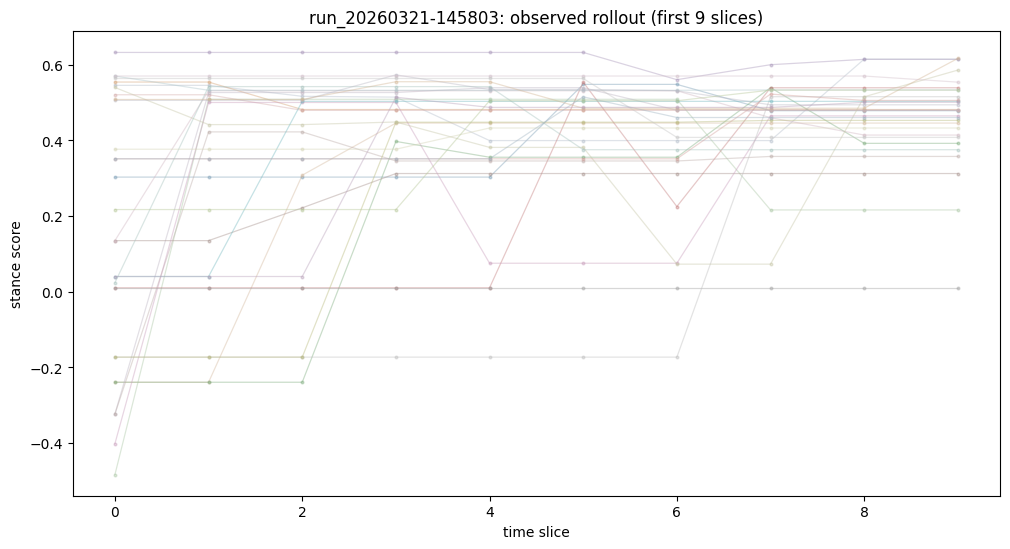

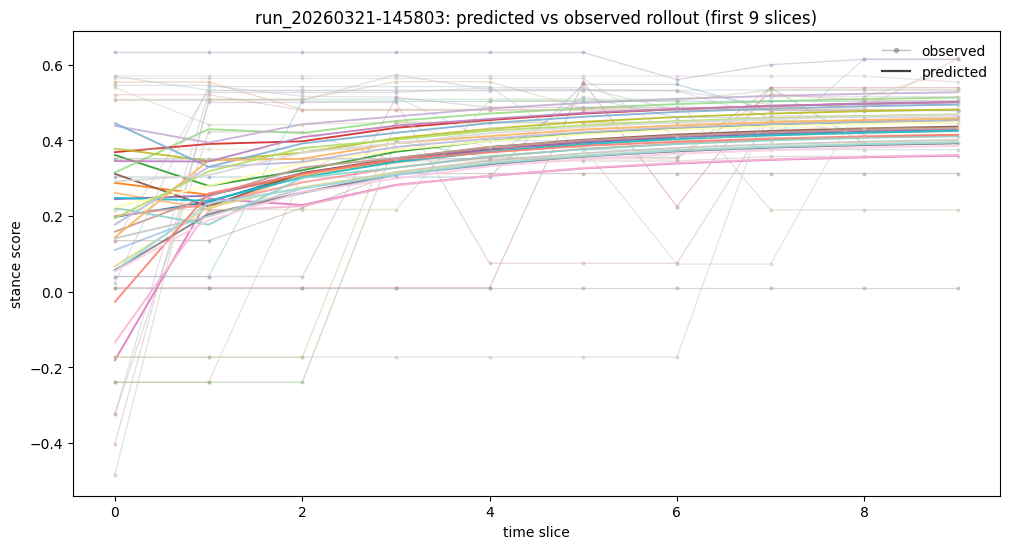

Average steady-state mean (observed): 0.4526355247768523
Average steady-state mean (predicted): 0.42321169585178053
Average steady-state variance (observed): 0.012182569717966543
Average steady-state variance (predicted): 0.0020007995562441533
Average Wasserstein distance: 0.1021


In [19]:
joint_fj = fit_friedkin_johnsen_joint(RUN_TRAJ, RUN_NEIGHBORS, GLOBAL_INIT_BY_AGENT, eps=1e-4)
JOINT_L1 = joint_fj['lambda1']
JOINT_L2 = joint_fj['lambda2']
JOINT_ALPHA = joint_fj['alpha']
JOINT_B = joint_fj['b']
JOINT_W = joint_fj['W']

print('Joint FJ fit (reparameterized)')
print('lambda1:', JOINT_L1)
print('lambda2:', JOINT_L2)
print('alpha = 1-lambda1-lambda2:', JOINT_ALPHA)
print('b:', JOINT_B)
print('Global MSE loss:', joint_fj['mse_pool'])

#print(JOINT_W)


PREDICTED_TRAJ_FJ_JOINT = {
    rn: friedkin_johnsen_rollout_prediction(
        JOINT_W,
        JOINT_B,
        build_x0_from_agent_inits(GLOBAL_INIT_BY_AGENT, N),
        PARAMS['rollout_horizon_cap'],
        JOINT_L1,
        JOINT_L2,
    )
    for rn, tr in RUN_TRAJ.items()
}

run_names = sorted(RUN_TRAJ.keys())

run_id = run_names[15]
plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_FJ_JOINT[run_id], GLOBAL_AGENT_IDS, 10)
per_run_metrics_joint = []
per_run_wass_joint = []

for rn in run_names:
    obs = np.asarray(RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PREDICTED_TRAJ_FJ_JOINT[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]
    per_run_metrics_joint.append(calculate_mean_and_variance(obs, pred, last_n=3))
    per_run_wass_joint.append(compute_wasserstein_distance(obs, pred))

avg_mean_obs_joint = float(np.mean([m['steady_mean_obs'] for m in per_run_metrics_joint]))
avg_mean_pred_joint = float(np.mean([m['steady_mean_pred'] for m in per_run_metrics_joint]))
avg_var_obs_joint = float(np.mean([m['steady_var_obs'] for m in per_run_metrics_joint]))
avg_var_pred_joint = float(np.mean([m['steady_var_pred'] for m in per_run_metrics_joint]))
avg_wasserstein_joint = float(np.mean(per_run_wass_joint))

print(f"Average steady-state mean (observed): {avg_mean_obs_joint}")
print(f"Average steady-state mean (predicted): {avg_mean_pred_joint}")
print(f"Average steady-state variance (observed): {avg_var_obs_joint}")
print(f"Average steady-state variance (predicted): {avg_var_pred_joint}")
print(f"Average Wasserstein distance: {avg_wasserstein_joint:.4f}")

In [20]:
from plot_utils import compute_fj_joint_eigenvalue

fj_joint_eig_result = compute_fj_joint_eigenvalue(
    joint_fj['X_pool'],
    joint_fj['Y_pool'],
    z0=build_x0_from_agent_inits(GLOBAL_INIT_BY_AGENT, N),
)

print('FJ joint eigenvalues:', len(fj_joint_eig_result['eigvals_full']))
print('gram full shape:', fj_joint_eig_result['gram_full_shape'])
print(fj_joint_eig_result['eigvals_full'])

FJ joint eigenvalues: 902
gram full shape: (902, 902)
[2.66287133e+00 2.72257672e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 3.07338208e+00 3.33425155e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.52365225e+00 3.74742930e+00 

In [21]:
def fit_friedkin_johnsen_joint_traj0(run_traj_map,run_neighbors,eps=1e-4):
    run_names=sorted(run_traj_map.keys())
    ref_neighbors=run_neighbors[run_names[0]]

    for rn in run_names[1:]:
        if run_neighbors[rn]!=ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')
        
    X_blocks=[]
    Y_blocks=[]
    X0_blocks=[]
    for rn in run_names:
        traj=np.asarray(run_traj_map[rn],dtype=float)
        X,Y=build_dataset_from_run(traj)
        X_blocks.append(X)
        Y_blocks.append(Y)
        X0_blocks.append(np.repeat(traj[0].reshape(1,-1),X.shape[0],axis=0))

    X_pool=np.vstack(X_blocks)
    Y_pool=np.vstack(Y_blocks)
    X0_pool=np.vstack(X0_blocks)
    _,n=X_pool.shape

    lambda1=cp.Variable(nonneg=True)
    lambda2=cp.Variable(nonneg=True)
    b_tilde=cp.Variable()
    alpha=1.0-lambda1-lambda2
    W_tilde=cp.Variable((n,n))
    ones_n=np.ones((n,),dtype=float)
    residual=Y_pool-(lambda1*X0_pool+b_tilde*ones_n[None,:]+X_pool@W_tilde.T)
    objective=cp.Minimize(cp.sum_squares(residual))
    constraints=[lambda2>=eps, lambda1+lambda2<=1.0-eps,lambda1<=1.0]

    for i in range(n):
        ns=ref_neighbors[i]
        allowed=np.zeros((n,),dtype=float)
        allowed[np.asarray(ns,dtype=int)]=1.0
        constraints.append(W_tilde[i,:]>=0)
        constraints.append(cp.sum(W_tilde[i,:])==alpha)
        constraints.append(cp.multiply(1.0-allowed,W_tilde[i,:])==0)
    constraints+=[b_tilde<=lambda2,b_tilde>=-lambda2]
    prob=cp.Problem(objective,constraints)
    prob.solve(solver=cp.OSQP)

    if lambda1.value is None or lambda2.value is None or W_tilde.value is None or b_tilde.value is None:
        raise RuntimeError('Joint FJ traj0 optimization failed to produce a solution.')
    lambda1_hat=float(lambda1.value)
    lambda2_hat=float(lambda2.value)
    alpha_hat=1.0-lambda1_hat-lambda2_hat
    b_tilde_hat=float(b_tilde.value)
    W_tilde_hat=np.asarray(W_tilde.value,dtype=float)
    if alpha_hat<=eps:
        raise RuntimeError(f'Estimated alpha too small for stable W recovery: alpha={alpha_hat}')
    
    W_hat=W_tilde_hat/alpha_hat
    b_hat=b_tilde_hat/lambda2_hat
    fitted_pool=lambda1_hat*X0_pool+b_tilde_hat*ones_n[None,:]+X_pool@W_tilde_hat.T
    mse_pool=float(np.mean((Y_pool-fitted_pool)**2))
    return {'lambda1':lambda1_hat,'lambda2':lambda2_hat,'alpha':alpha_hat,'b_tilde':b_tilde_hat,'W_tilde':W_tilde_hat,'W':W_hat,'b':float(b_hat),'X_pool':X_pool,'Y_pool':Y_pool,'X0_pool':X0_pool,'mse_pool':mse_pool,'status':prob.status,'objective':float(prob.value) if prob.value is not None else np.nan}

Joint FJ fit (reparameterized)
lambda1: 0.22191843497873973
lambda2: 0.15095988280669004
alpha = 1-lambda1-lambda2: 0.6271216822145702
b: 0.6770240799334261
Global MSE loss: 0.02188578317996497


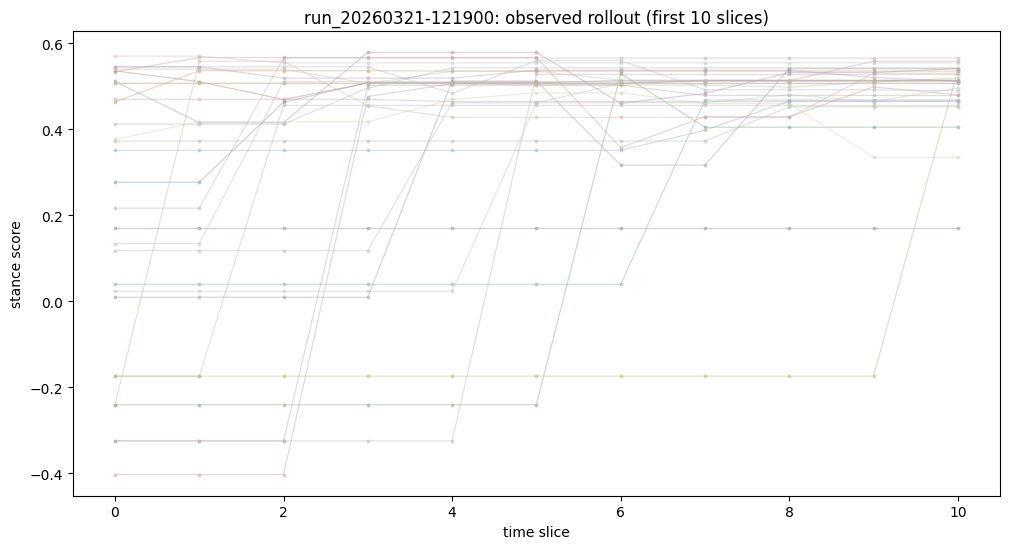

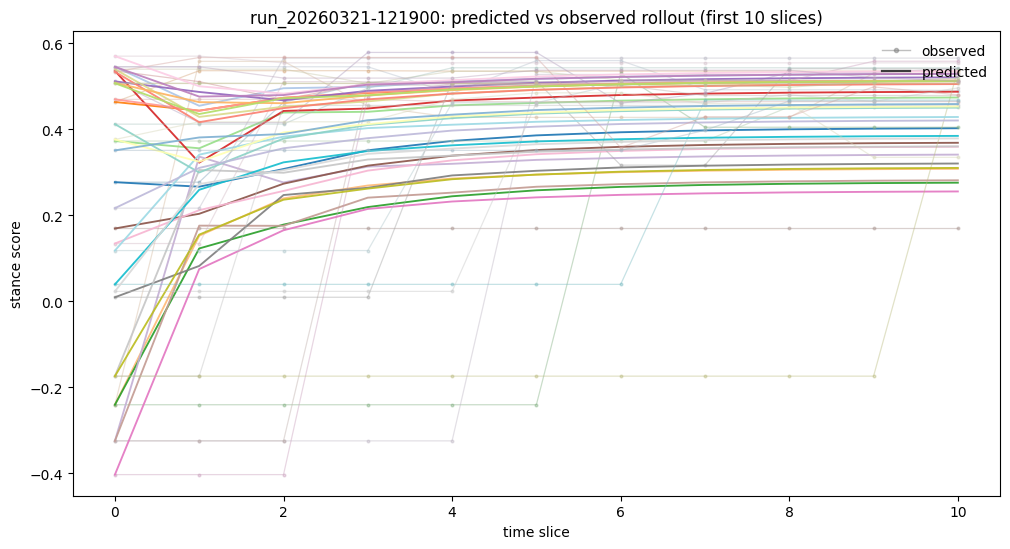

Average steady-state mean (observed): 0.4526355247768523
Average steady-state mean (predicted): 0.44559617637350074
Average steady-state variance (observed): 0.012182569717966543
Average steady-state variance (predicted): 0.004707942915605257
Average Wasserstein distance: 0.0633


In [22]:
joint_fj = fit_friedkin_johnsen_joint_traj0(RUN_TRAJ, RUN_NEIGHBORS, eps=1e-4)
JOINT_L1 = joint_fj['lambda1']
JOINT_L2 = joint_fj['lambda2']
JOINT_ALPHA = joint_fj['alpha']
JOINT_B = joint_fj['b']
JOINT_W = joint_fj['W']

print('Joint FJ fit (reparameterized)')
print('lambda1:', JOINT_L1)
print('lambda2:', JOINT_L2)
print('alpha = 1-lambda1-lambda2:', JOINT_ALPHA)
print('b:', JOINT_B)
print('Global MSE loss:', joint_fj['mse_pool'])

#print(JOINT_W)


PREDICTED_TRAJ_FJ_JOINT = {
    rn: friedkin_johnsen_rollout_prediction(
        JOINT_W,
        JOINT_B,
        np.asarray(RUN_TRAJ[rn],dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        JOINT_L1,
        JOINT_L2,
    )
    for rn, tr in RUN_TRAJ.items()
}

run_names = sorted(RUN_TRAJ.keys())

run_id = run_names[10]
plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_FJ_JOINT[run_id], GLOBAL_AGENT_IDS, 10)
per_run_metrics_joint = []
per_run_wass_joint = []

for rn in run_names:
    obs = np.asarray(RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PREDICTED_TRAJ_FJ_JOINT[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]
    per_run_metrics_joint.append(calculate_mean_and_variance(obs, pred, last_n=3))
    per_run_wass_joint.append(compute_wasserstein_distance(obs, pred))

avg_mean_obs_joint = float(np.mean([m['steady_mean_obs'] for m in per_run_metrics_joint]))
avg_mean_pred_joint = float(np.mean([m['steady_mean_pred'] for m in per_run_metrics_joint]))
avg_var_obs_joint = float(np.mean([m['steady_var_obs'] for m in per_run_metrics_joint]))
avg_var_pred_joint = float(np.mean([m['steady_var_pred'] for m in per_run_metrics_joint]))
avg_wasserstein_joint = float(np.mean(per_run_wass_joint))

print(f"Average steady-state mean (observed): {avg_mean_obs_joint}")
print(f"Average steady-state mean (predicted): {avg_mean_pred_joint}")
print(f"Average steady-state variance (observed): {avg_var_obs_joint}")
print(f"Average steady-state variance (predicted): {avg_var_pred_joint}")
print(f"Average Wasserstein distance: {avg_wasserstein_joint:.4f}")

In [23]:
from plot_utils import compute_fj_joint_eigenvalue

fj_joint_eig_result = compute_fj_joint_eigenvalue(
    joint_fj['X_pool'],
    joint_fj['Y_pool'],
    z0=np.asarray(RUN_TRAJ[rn],dtype=float)[0],
)

print('FJ joint eigenvalues:', len(fj_joint_eig_result['eigvals_full']))
print('gram full shape:', fj_joint_eig_result['gram_full_shape'])
print(fj_joint_eig_result['eigvals_full'])

FJ joint eigenvalues: 902
gram full shape: (902, 902)
[2.71802621e+00 2.72258953e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 2.74523277e+00 2.74523277e+00
 2.74523277e+00 2.74523277e+00 3.31710893e+00 3.33429683e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.39126872e+00 3.39126872e+00 3.39126872e+00 3.39126872e+00
 3.71683675e+00 3.74751493e+00 

## Graph Adjacency Matrix

In [24]:
import cvxpy as cp

def build_row_normalized_adjacency(neighbors, n):
    A = np.zeros((n, n), dtype=float)
    for i in range(n):
        row_neighbors = list(neighbors[i])
        if len(row_neighbors) == 0:
            A[i, i] = 1.0
            continue
        row_neighbors = [j for j in row_neighbors if 0 <= j < n]
        if len(row_neighbors) == 0:
            A[i, i] = 1.0
            continue
        A[i, row_neighbors] = 1.0 / len(row_neighbors)
    return A

def fit_friedkin_johnsen_adjacency(run_traj_map, run_neighbors, lambda1, lambda2):
    if lambda1 < 0 or lambda2 < 0 or lambda1 + lambda2 > 1:
        raise ValueError('lambda1 and lambda2 must be nonnegative and satisfy lambda1 + lambda2 <= 1')

    run_names = sorted(run_traj_map.keys())
    ref_neighbors = run_neighbors[run_names[0]]

    for rn in run_names[1:]:
        if run_neighbors[rn] != ref_neighbors:
            raise ValueError('RUN_NEIGHBORS must be identical across runs for pooled fitting.')

    X_blocks = []
    Y_blocks = []
    X0_blocks = []

    for rn in run_names:
        traj = np.asarray(run_traj_map[rn], dtype=float)
        X, Y = build_dataset_from_run(traj)
        X_blocks.append(X)
        Y_blocks.append(Y)
        X0_blocks.append(np.repeat(traj[0].reshape(1, -1), X.shape[0], axis=0))

    X_pool = np.vstack(X_blocks)
    Y_pool = np.vstack(Y_blocks)
    X0_pool = np.vstack(X0_blocks)

    n = X_pool.shape[1]
    Abar = build_row_normalized_adjacency(ref_neighbors, n)
    alpha = 1.0 - lambda1 - lambda2

    gamma = cp.Variable()
    bias = cp.Variable()

    bias_vec = bias * np.ones((n,), dtype=float)
    pred_pool = (
        lambda1 * X0_pool
        + lambda2 * bias_vec[None, :]
        + alpha * (gamma * (X_pool @ Abar.T) + (1.0 - gamma) * X_pool)
    )

    objective = cp.Minimize(cp.sum_squares(Y_pool - pred_pool))
    constraints = [
        gamma >= 0,
        gamma <= 1,
        bias >= -1,
        bias <= 1,
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)

    if gamma.value is None or bias.value is None:
        raise RuntimeError('Adjacency-based FJ optimization failed to produce a solution.')

    gamma_hat = float(gamma.value)
    bias_hat = float(bias.value)
    W_hat = gamma_hat * Abar + (1.0 - gamma_hat) * np.eye(n, dtype=float)
    fitted_pool = (
        lambda1 * X0_pool
        + lambda2 * bias_hat * np.ones((1, n), dtype=float)
        + alpha * (X_pool @ W_hat.T)
    )
    mse_pool = float(np.mean((Y_pool - fitted_pool) ** 2))

    return {
        'gamma': gamma_hat,
        'bias': bias_hat,
        'Abar': Abar,
        'W': W_hat,
        'X_pool': X_pool,
        'Y_pool': Y_pool,
        'X0_pool': X0_pool,
        'mse_pool': mse_pool,
        'status': problem.status,
        'objective': float(problem.value) if problem.value is not None else np.nan,
    }



In [25]:
def friedkin_johnsen_adjacency_rollout(W, bias, x0, horizon, lambda1, lambda2):
    alpha = 1.0 - lambda1 - lambda2
    x0 = np.asarray(x0, dtype=float)
    current_x = x0.copy()
    predictions = [current_x.copy()]
    bias_vec = np.full_like(current_x, float(bias), dtype=float)

    for _ in range(horizon):
        current_x = lambda1 * x0 + lambda2 * bias_vec + alpha * (W @ current_x)
        predictions.append(current_x.copy())

    return predictions

Adjacency-based Friedkin-Johnsen fit
lambda1: 0.1
lambda2: 0.3
gamma: 0.009231764298348046
bias: 0.5112395679103535
Global pooled MSE loss: 0.011997138467948091
Status: optimal


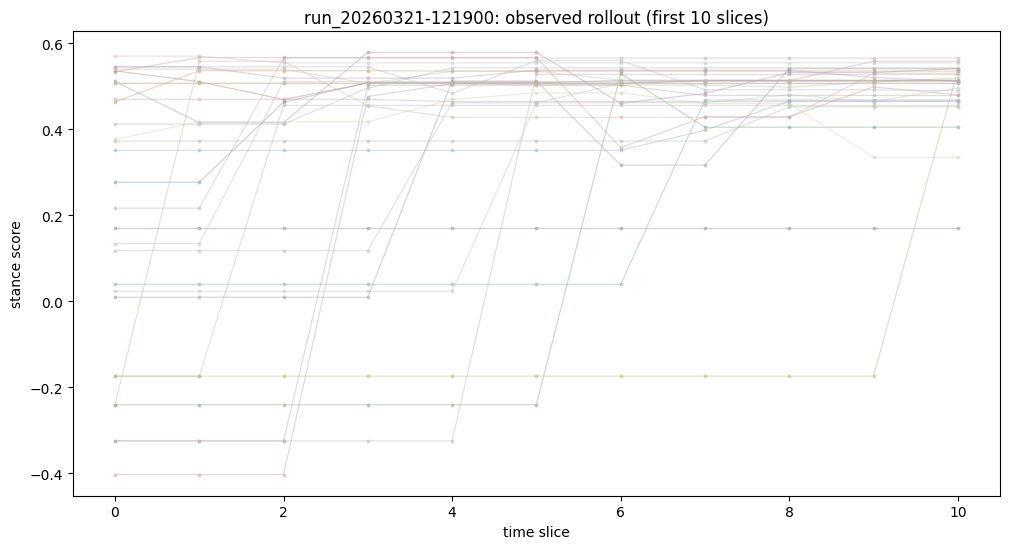

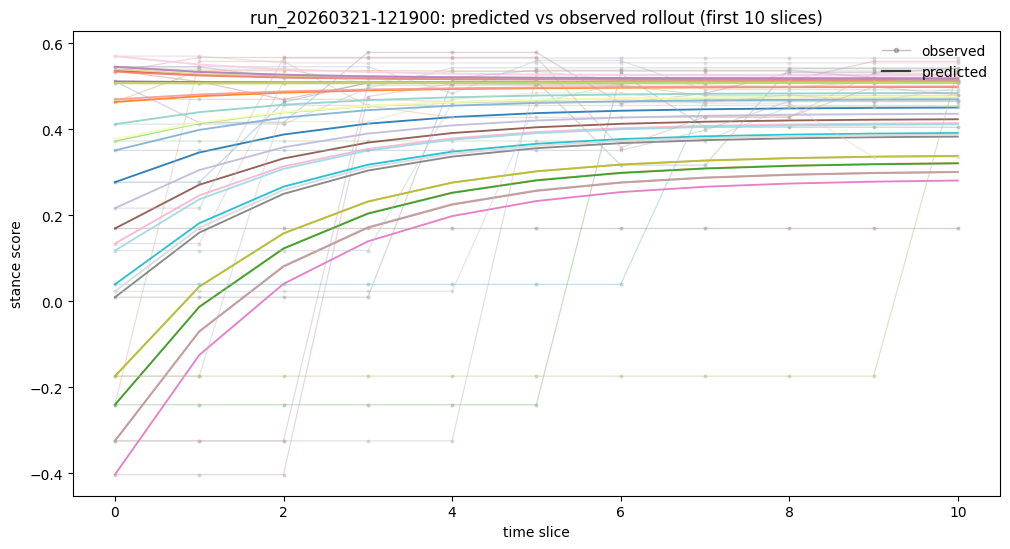

Average steady-state mean (observed): 0.4526355247768523
Average steady-state mean (predicted): 0.44765045047710705
Average steady-state variance (observed): 0.012182569717966543
Average steady-state variance (predicted): 0.004866745263435219
Average Wasserstein distance: 0.0532


In [26]:
FJ_ADJ_LAMBDA1 = 0.1
FJ_ADJ_LAMBDA2 = 0.3

fj_adj = fit_friedkin_johnsen_adjacency(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    FJ_ADJ_LAMBDA1,
    FJ_ADJ_LAMBDA2,
 )

print('Adjacency-based Friedkin-Johnsen fit')
print('lambda1:', FJ_ADJ_LAMBDA1)
print('lambda2:', FJ_ADJ_LAMBDA2)
print('gamma:', fj_adj['gamma'])
print('bias:', fj_adj['bias'])
print('Global pooled MSE loss:', fj_adj['mse_pool'])
print('Status:', fj_adj['status'])

PREDICTED_TRAJ_FJ_ADJ = {
    rn: friedkin_johnsen_adjacency_rollout(
        fj_adj['W'],
        fj_adj['bias'],
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_LAMBDA1,
        FJ_ADJ_LAMBDA2,
    )
    for rn in sorted(RUN_TRAJ.keys())
}

run_names = sorted(RUN_TRAJ.keys())
run_id = run_names[10]

plot_observed_trajectories(run_id, RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, 10)
plot_predicted_vs_observed(run_id, RUN_TRAJ[run_id], PREDICTED_TRAJ_FJ_ADJ[run_id], GLOBAL_AGENT_IDS, 10)

per_run_metrics_adj = []
per_run_wass_adj = []

for rn in run_names:
    obs = np.asarray(RUN_TRAJ[rn], dtype=float)
    pred = np.asarray(PREDICTED_TRAJ_FJ_ADJ[rn], dtype=float)
    T = min(obs.shape[0], pred.shape[0])
    obs = obs[:T]
    pred = pred[:T]

    per_run_metrics_adj.append(calculate_mean_and_variance(obs, pred, last_n=3))
    per_run_wass_adj.append(compute_wasserstein_distance(obs, pred))

avg_mean_obs_adj = float(np.mean([m['steady_mean_obs'] for m in per_run_metrics_adj]))
avg_mean_pred_adj = float(np.mean([m['steady_mean_pred'] for m in per_run_metrics_adj]))
avg_var_obs_adj = float(np.mean([m['steady_var_obs'] for m in per_run_metrics_adj]))
avg_var_pred_adj = float(np.mean([m['steady_var_pred'] for m in per_run_metrics_adj]))
avg_wasserstein_adj = float(np.mean(per_run_wass_adj))

print(f"Average steady-state mean (observed): {avg_mean_obs_adj}")
print(f"Average steady-state mean (predicted): {avg_mean_pred_adj}")
print(f"Average steady-state variance (observed): {avg_var_obs_adj}")
print(f"Average steady-state variance (predicted): {avg_var_pred_adj}")
print(f"Average Wasserstein distance: {avg_wasserstein_adj:.4f}")

In [27]:
from plot_utils import compute_fj_eigenvalue

fj_adj_eig_result = compute_fj_eigenvalue(
    fj_adj['X_pool'],
    fj_adj['Y_pool'],
    lambda_1=FJ_ADJ_LAMBDA1,
    lambda_2=FJ_ADJ_LAMBDA2,
)

print('FJ adjacency eigenvalues:', len(fj_adj_eig_result['eigvals_full']))
print('gram full shape:', fj_adj_eig_result['gram_full_shape'])
print(fj_adj_eig_result['eigvals_full'])

FJ adjacency eigenvalues: 901
gram full shape: (901, 901)
[9.79685026e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 9.88283797e-01 9.88283797e-01
 9.88283797e-01 9.88283797e-01 1.19873813e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.22085674e+00 1.22085674e+00 1.22085674e+00 1.22085674e+00
 1.34610699e+00 1.39210217e

In [28]:
def align_rollout_pair(observed, predicted):
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    T = min(observed.shape[0], predicted.shape[0])
    return observed[:T], predicted[:T]


def stack_curves(curves):
    curves = [np.asarray(curve, dtype=float).ravel() for curve in curves if len(curve) > 0]
    if not curves:
        return np.empty((0, 0), dtype=float)
    common_T = min(curve.shape[0] for curve in curves)
    return np.stack([curve[:common_T] for curve in curves], axis=0)


def evaluate_validation_model(validation_traj_map, rollout_fn):
    run_names = sorted(validation_traj_map.keys())
    per_run = {}
    mean_true_curves = []
    mean_pred_curves = []
    var_true_curves = []
    var_pred_curves = []
    wasserstein_curves = []
    transition_mses = []

    for rn in run_names:
        observed = np.asarray(validation_traj_map[rn], dtype=float)
        predicted = np.asarray(rollout_fn(observed), dtype=float)
        observed, predicted = align_rollout_pair(observed, predicted)

        mean_true, mean_pred = compute_mean_per_timestep(observed, predicted)
        var_true, var_pred = compute_variance_per_timestep(observed, predicted)
        wasserstein_curve = compute_wasserstein_distance_per_timestep(observed, predicted)

        transition_mses.append(float(np.mean((observed - predicted) ** 2)))
        mean_true_curves.append(mean_true)
        mean_pred_curves.append(mean_pred)
        var_true_curves.append(var_true)
        var_pred_curves.append(var_pred)
        wasserstein_curves.append(wasserstein_curve)

        per_run[rn] = {
            'observed': observed,
            'predicted': predicted,
            'mean_true': mean_true,
            'mean_pred': mean_pred,
            'var_true': var_true,
            'var_pred': var_pred,
            'wasserstein': wasserstein_curve,
            'transition_mse': float(np.mean((observed - predicted) ** 2)),
        }

    mean_true_stack = stack_curves(mean_true_curves)
    mean_pred_stack = stack_curves(mean_pred_curves)
    var_true_stack = stack_curves(var_true_curves)
    var_pred_stack = stack_curves(var_pred_curves)
    wasserstein_stack = stack_curves(wasserstein_curves)

    return {
        'per_run': per_run,
        'mean_true_stack': mean_true_stack,
        'mean_pred_stack': mean_pred_stack,
        'var_true_stack': var_true_stack,
        'var_pred_stack': var_pred_stack,
        'wasserstein_stack': wasserstein_stack,
        'transition_mse_mean': float(np.mean(transition_mses)),
        'mean_curve_abs_error': float(np.mean(np.abs(mean_true_stack - mean_pred_stack))) if mean_true_stack.size else np.nan,
        'var_curve_abs_error': float(np.mean(np.abs(var_true_stack - var_pred_stack))) if var_true_stack.size else np.nan,
        'wasserstein_curve_mean': float(np.mean(wasserstein_stack)) if wasserstein_stack.size else np.nan,
    }

In [29]:
# Training set stacked metric evaluations for all four models.
from plot_utils import (
    compute_mean_per_timestep,
    compute_variance_per_timestep,
    compute_wasserstein_distance_per_timestep,
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_predicted_vs_observed,
)
TRAIN_DEGROOT = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TRAIN_FJ_FIXED = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: friedkin_johnsen_rollout_prediction(
        FJ_W,
        FJ_b,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_LAMBDA1,
        FJ_LAMBDA2,
    ),
)
TRAIN_FJ_JOINT = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: friedkin_johnsen_rollout_prediction(
        JOINT_W,
        JOINT_B,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        JOINT_L1,
        JOINT_L2,
    ),
)
TRAIN_FJ_ADJ = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: friedkin_johnsen_adjacency_rollout(
        fj_adj['W'],
        fj_adj['bias'],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_LAMBDA1,
        FJ_ADJ_LAMBDA2,
    ),
)

Training metric horizon (shared): 5


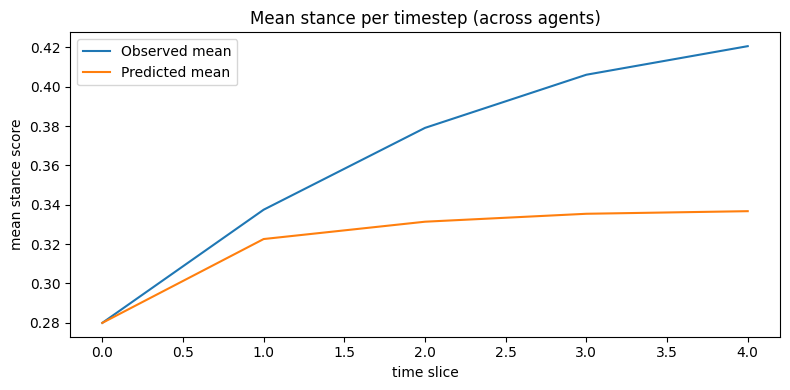

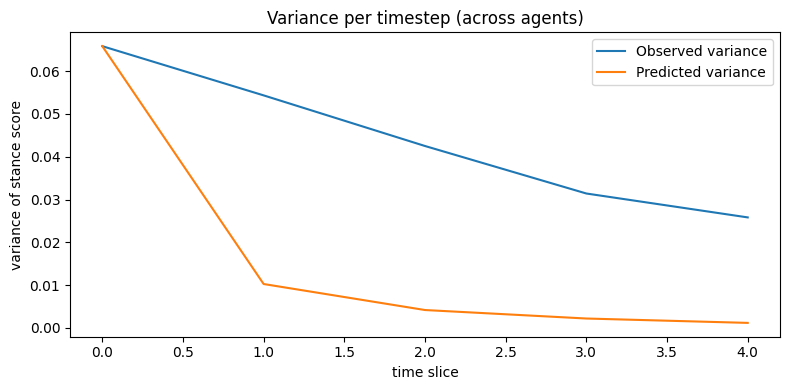

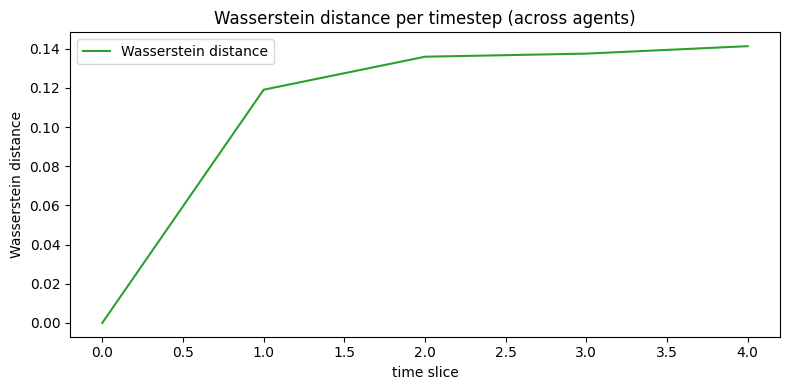

array([0.        , 0.11910054, 0.13596075, 0.13753823, 0.14134573])

In [30]:
# Use one shared curve horizon for all training metric plots (model-to-model consistency).
TRAIN_CURVE_HORIZON = min(
    TRAIN_DEGROOT['mean_true_stack'].shape[1],
    TRAIN_FJ_FIXED['mean_true_stack'].shape[1],
    TRAIN_FJ_JOINT['mean_true_stack'].shape[1],
    TRAIN_FJ_ADJ['mean_true_stack'].shape[1],
)

print('Training metric horizon (shared):', TRAIN_CURVE_HORIZON)

plot_mean_per_timestep(
    TRAIN_DEGROOT['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_DEGROOT['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_DEGROOT['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

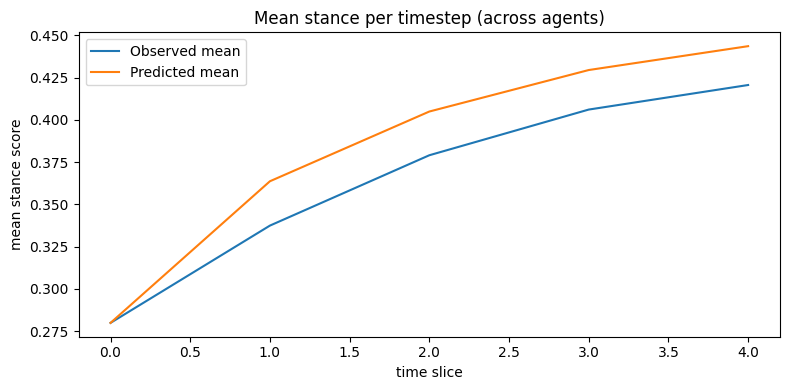

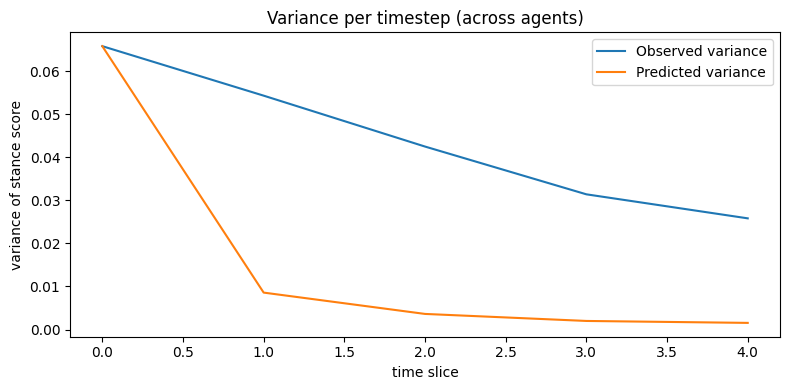

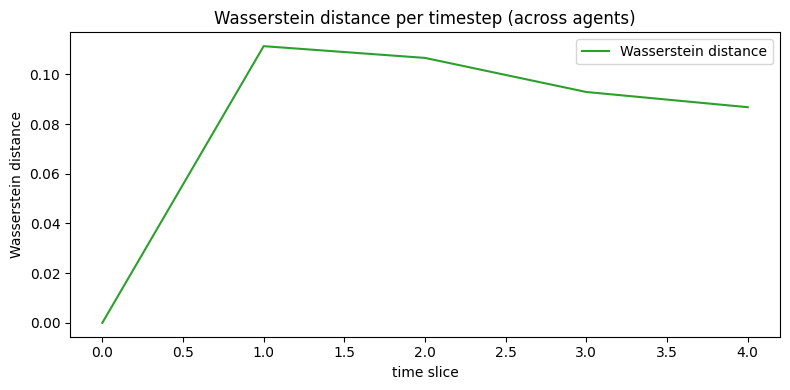

array([0.        , 0.11136511, 0.10663868, 0.09292265, 0.08680566])

In [31]:
plot_mean_per_timestep(
    TRAIN_FJ_FIXED['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_FIXED['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_FJ_FIXED['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_FIXED['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_FJ_FIXED['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

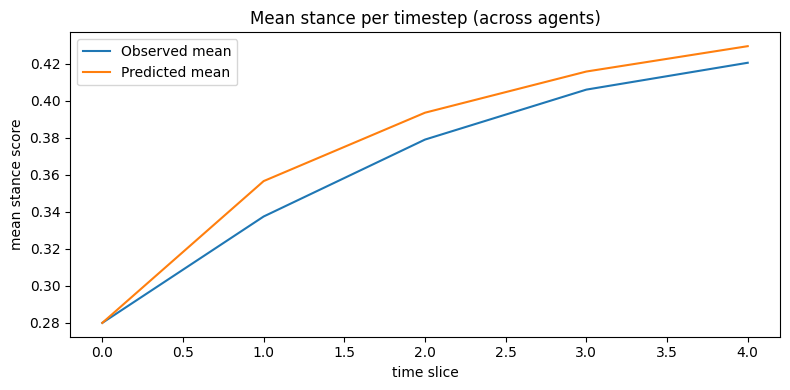

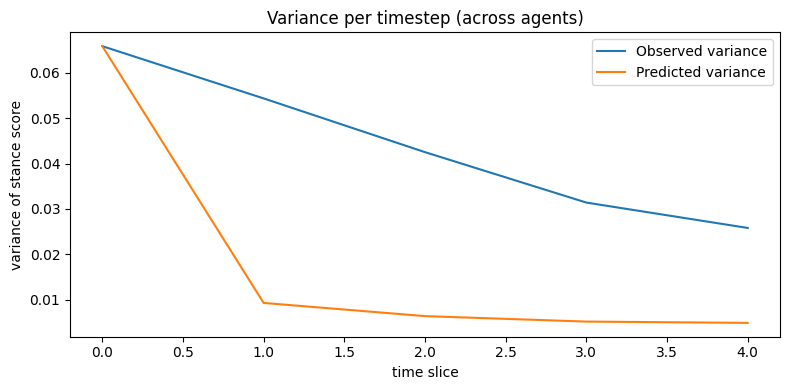

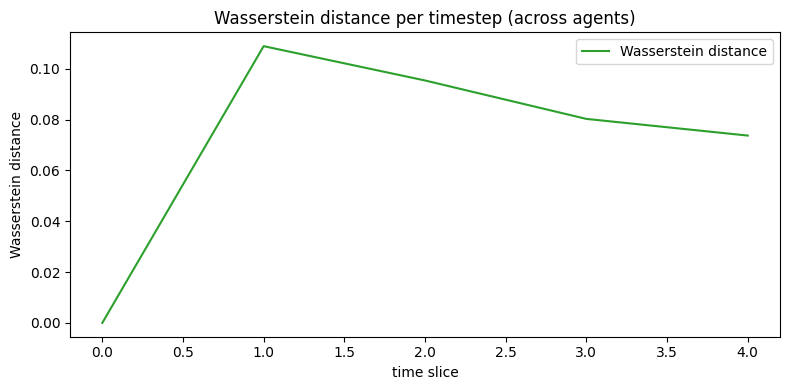

array([0.        , 0.10893758, 0.09543235, 0.0803051 , 0.07374489])

In [32]:
plot_mean_per_timestep(
    TRAIN_FJ_JOINT['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_JOINT['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_FJ_JOINT['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_JOINT['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_FJ_JOINT['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

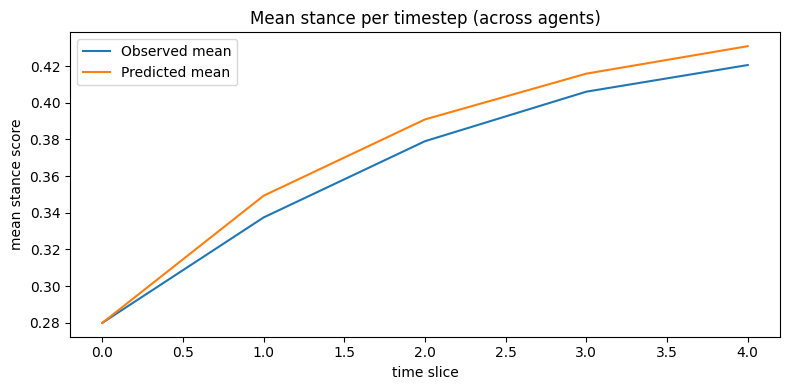

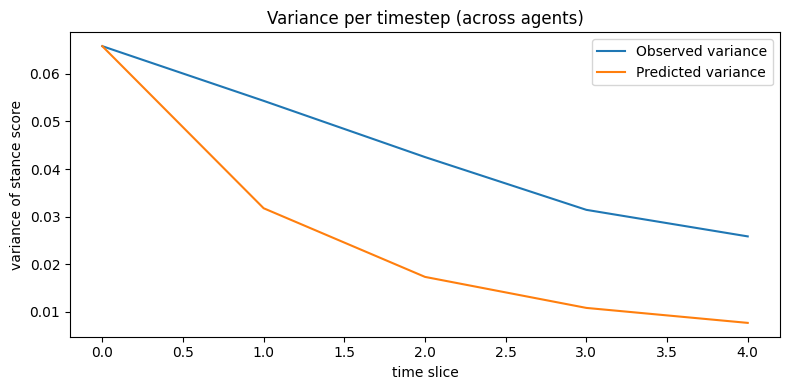

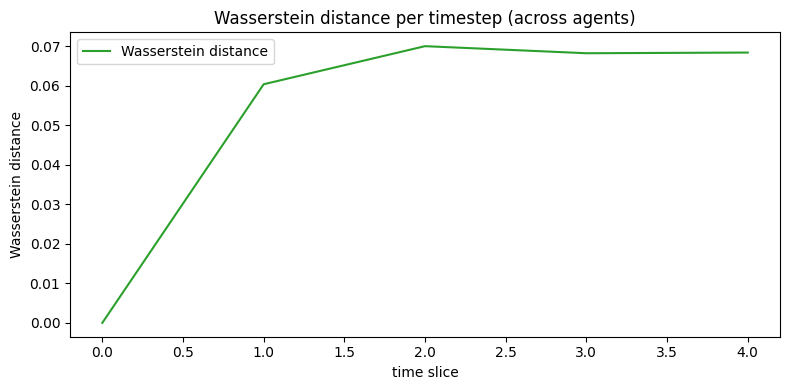

array([0.        , 0.0603525 , 0.06998506, 0.06819696, 0.06836997])

In [33]:
plot_mean_per_timestep(
    TRAIN_FJ_ADJ['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_ADJ['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_FJ_ADJ['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_ADJ['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_FJ_ADJ['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

## Validation

In [34]:
from plot_utils import (
    compute_mean_per_timestep,
    compute_variance_per_timestep,
    compute_wasserstein_distance_per_timestep,
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_predicted_vs_observed,
)

TEST_AGENT_FRACTION = 0.4
TEST_CONSTRAIN_MESSAGES = 150
TEST_DATA_ROOT = ROOT / 'init_conditions'



TEST_RUN_DIRS = sorted([p for p in TEST_DATA_ROOT.iterdir() if p.is_dir()])
TEST_RUN_DATA = {r.name: load_run_data(r) for r in TEST_RUN_DIRS}
TEST_RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=TEST_AGENT_FRACTION,
        return_post_mask=True,
        constrain_messages=TEST_CONSTRAIN_MESSAGES,
    )
    for rn, data in TEST_RUN_DATA.items()
}
TEST_RUN_TRAJ = {rn: tm[0] for rn, tm in TEST_RUN_TRAJ_AND_MASK.items()}
TEST_RUN_POST_MASK = {rn: tm[1] for rn, tm in TEST_RUN_TRAJ_AND_MASK.items()}
TEST_RUN_NEIGHBORS = {rn: build_neighbors_index(data, GLOBAL_AGENT_IDS) for rn, data in TEST_RUN_DATA.items()}
TEST_RUN_NAMES = sorted(TEST_RUN_TRAJ.keys())

In [35]:
TEST_DEGROOT = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TEST_FJ_FIXED = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: friedkin_johnsen_rollout_prediction(
        FJ_W,
        FJ_b,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_LAMBDA1,
        FJ_LAMBDA2,
    ),
)
TEST_FJ_JOINT = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: friedkin_johnsen_rollout_prediction(
        JOINT_W,
        JOINT_B,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        JOINT_L1,
        JOINT_L2,
    ),
)
TEST_FJ_ADJ = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: friedkin_johnsen_adjacency_rollout(
        fj_adj['W'],
        fj_adj['bias'],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_LAMBDA1,
        FJ_ADJ_LAMBDA2,
    ),
)

Validation metric horizon (shared): 5


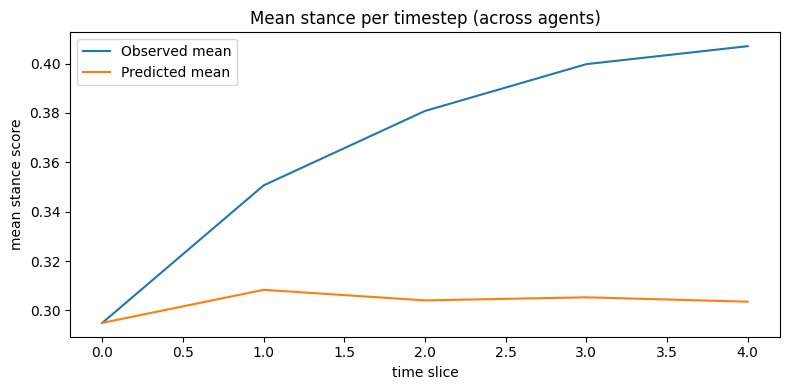

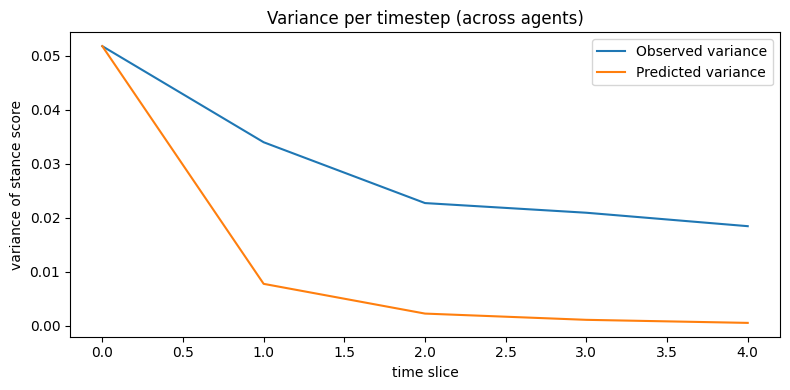

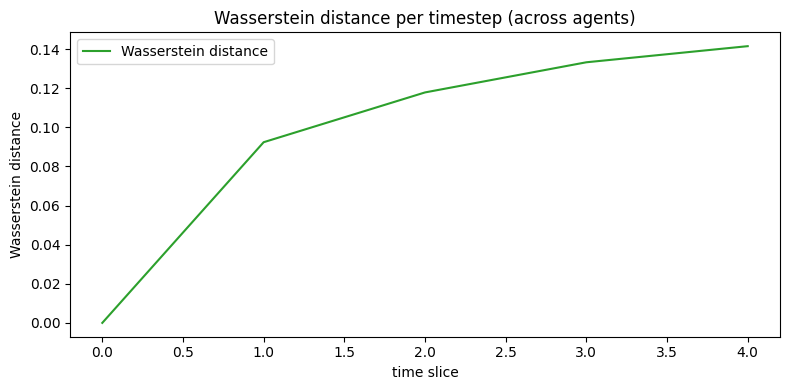

array([0.        , 0.09240741, 0.11786531, 0.13328407, 0.14152326])

In [36]:
# Use one shared curve horizon for all validation metric plots (model-to-model consistency).
VALIDATION_CURVE_HORIZON = min(
    TEST_DEGROOT['mean_true_stack'].shape[1],
    TEST_FJ_FIXED['mean_true_stack'].shape[1],
    TEST_FJ_JOINT['mean_true_stack'].shape[1],
    TEST_FJ_ADJ['mean_true_stack'].shape[1],
)

print('Validation metric horizon (shared):', VALIDATION_CURVE_HORIZON)

plot_mean_per_timestep(
    TEST_DEGROOT['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_DEGROOT['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_DEGROOT['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

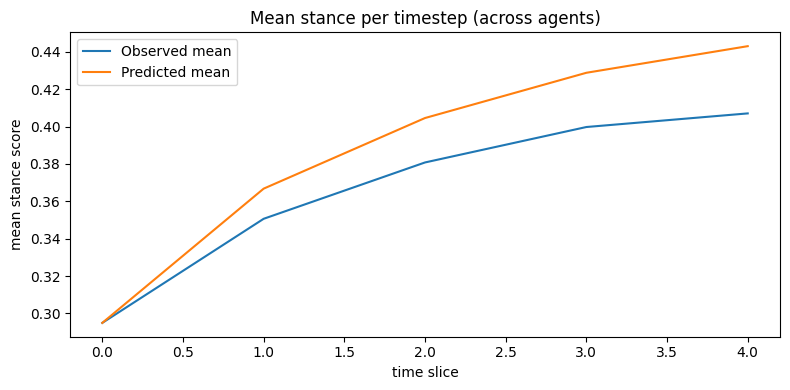

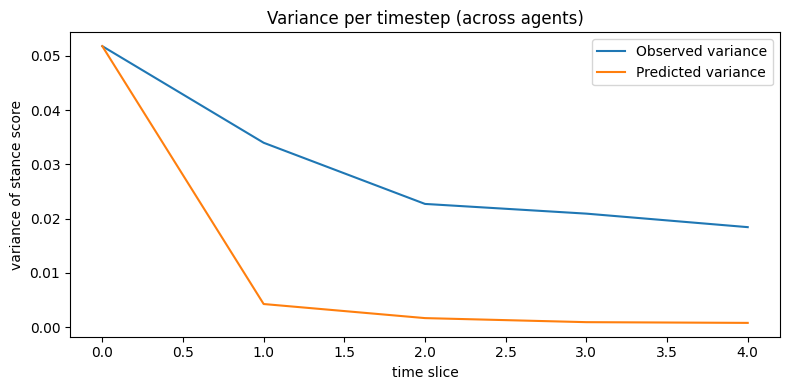

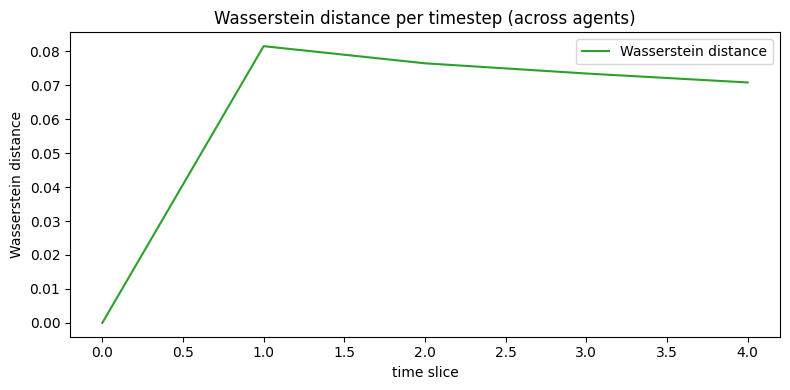

array([0.        , 0.08148414, 0.07643809, 0.0734309 , 0.07079358])

In [37]:
plot_mean_per_timestep(
    TEST_FJ_FIXED['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_FIXED['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_FJ_FIXED['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_FIXED['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_FJ_FIXED['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

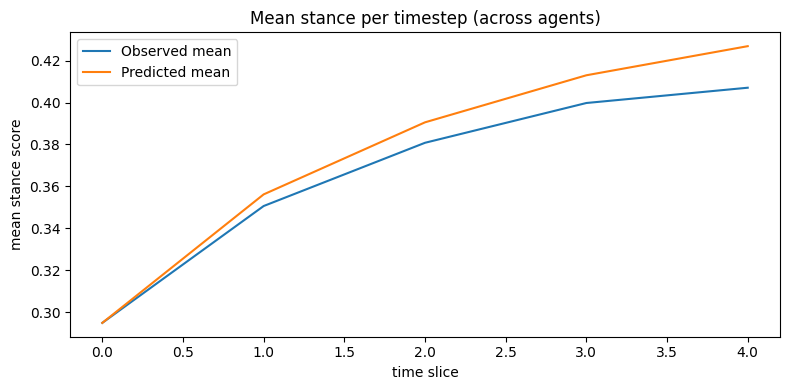

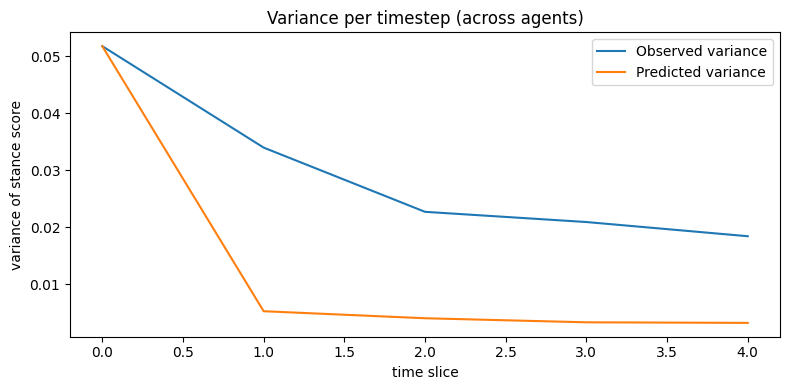

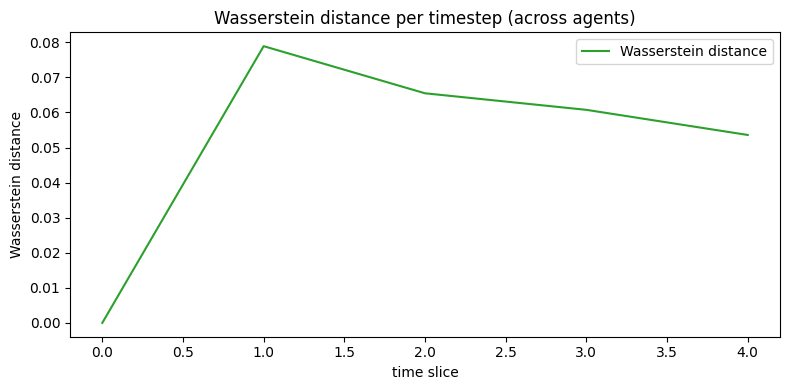

array([0.        , 0.07889939, 0.06546477, 0.06074687, 0.05358189])

In [38]:
plot_mean_per_timestep(
    TEST_FJ_JOINT['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_JOINT['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_FJ_JOINT['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_JOINT['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_FJ_JOINT['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

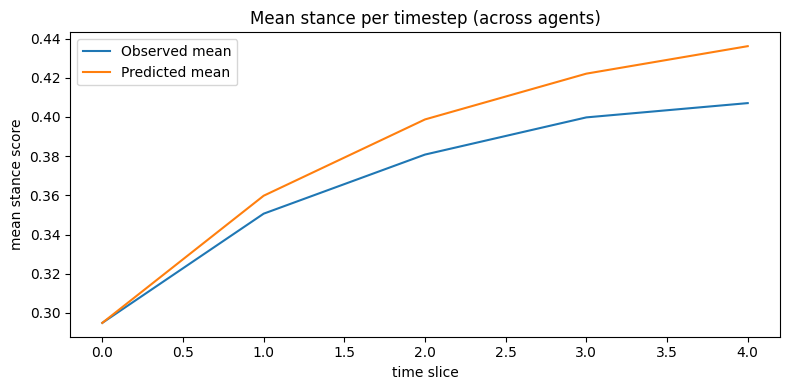

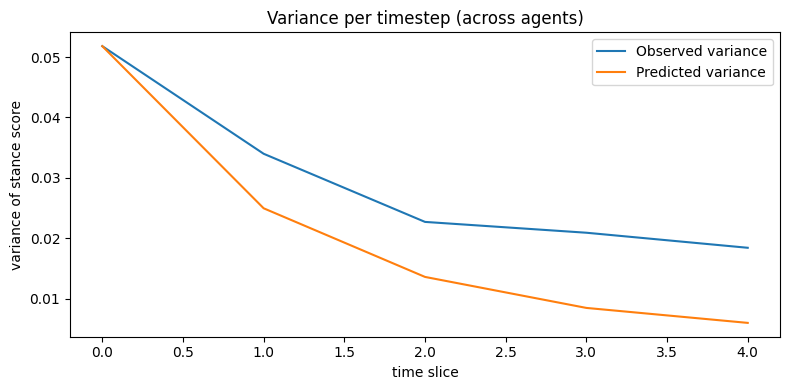

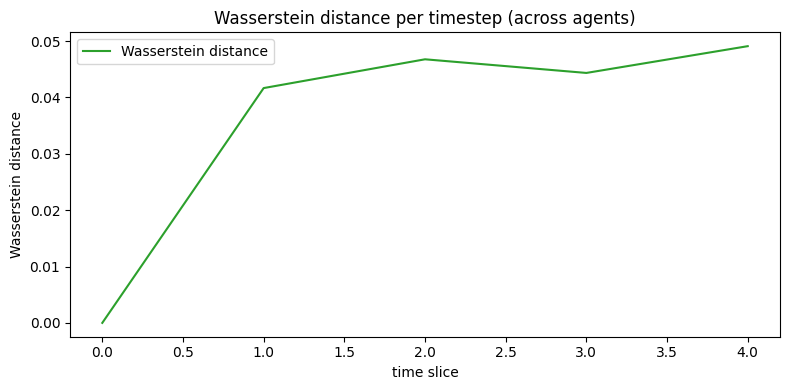

array([0.        , 0.0416538 , 0.0467589 , 0.04433913, 0.04908773])

In [39]:
plot_mean_per_timestep(
    TEST_FJ_ADJ['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_ADJ['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_FJ_ADJ['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_ADJ['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_FJ_ADJ['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

Validation sample run: run_20260414-043038
Plot horizon (slices): 9


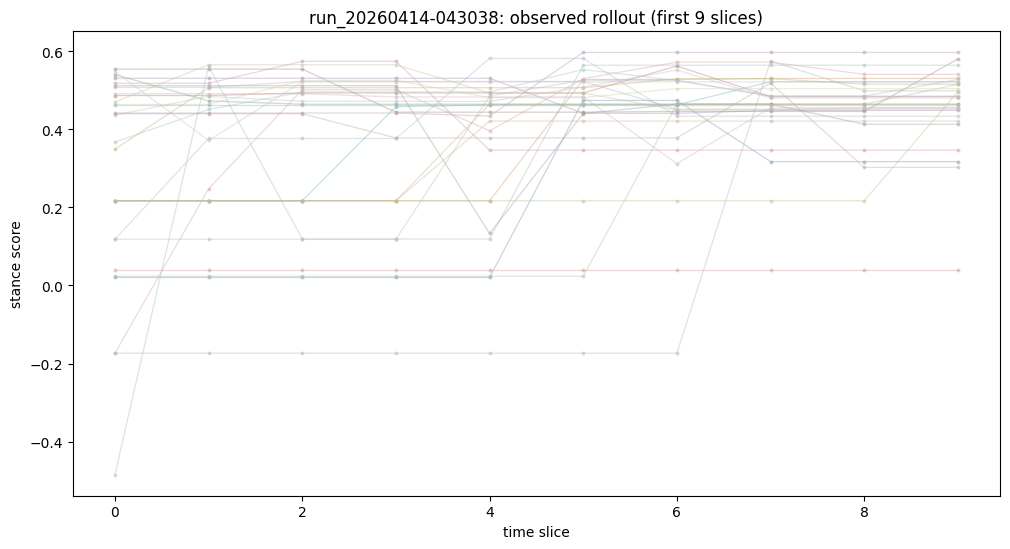

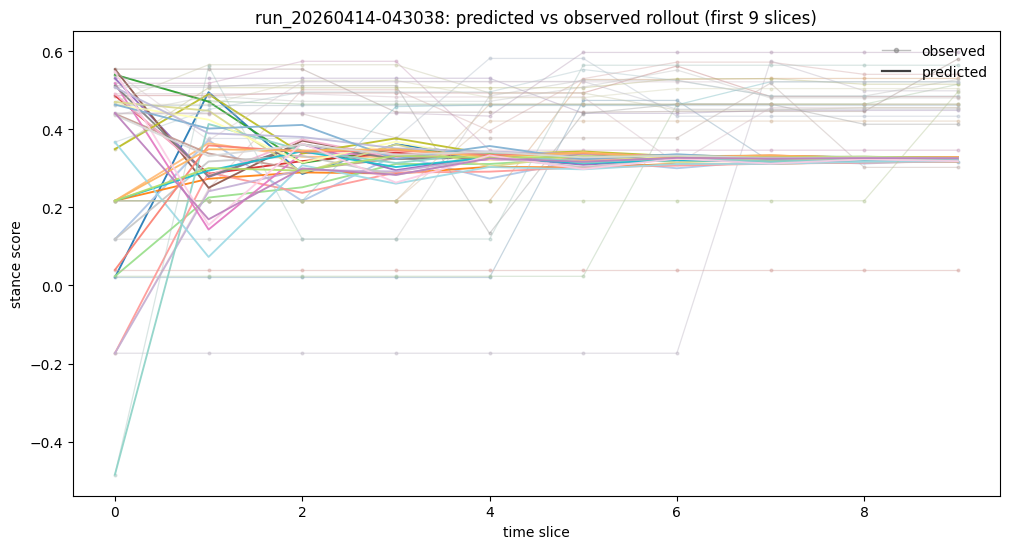

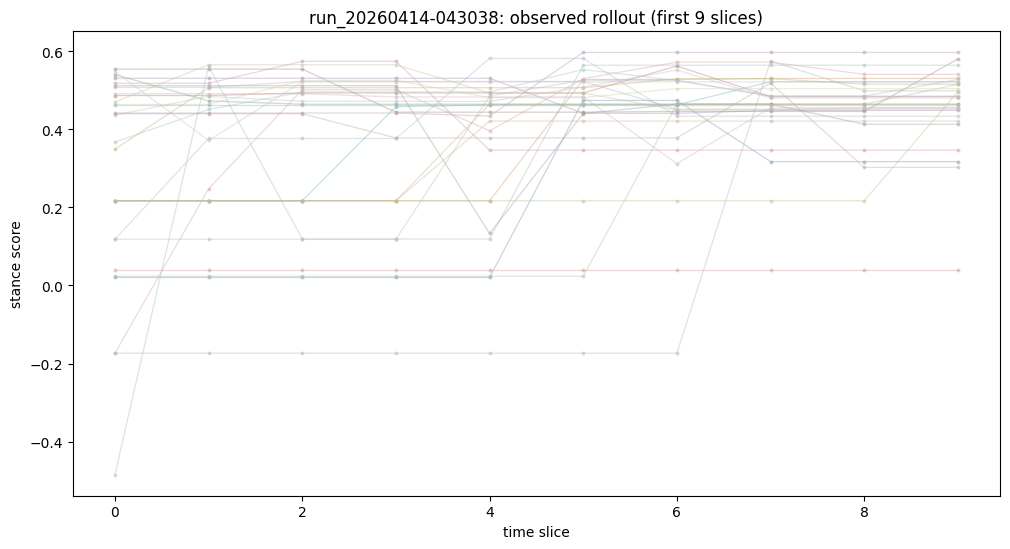

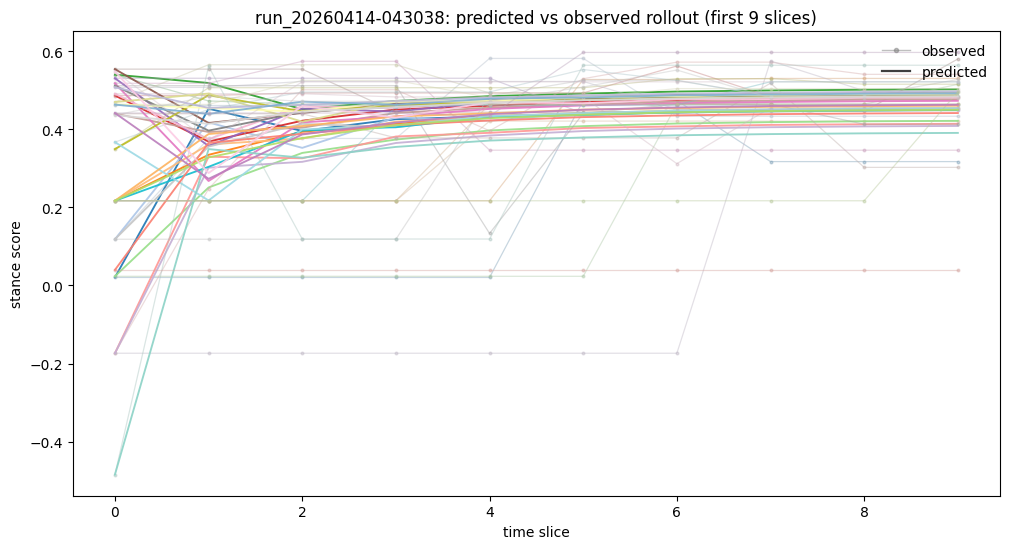

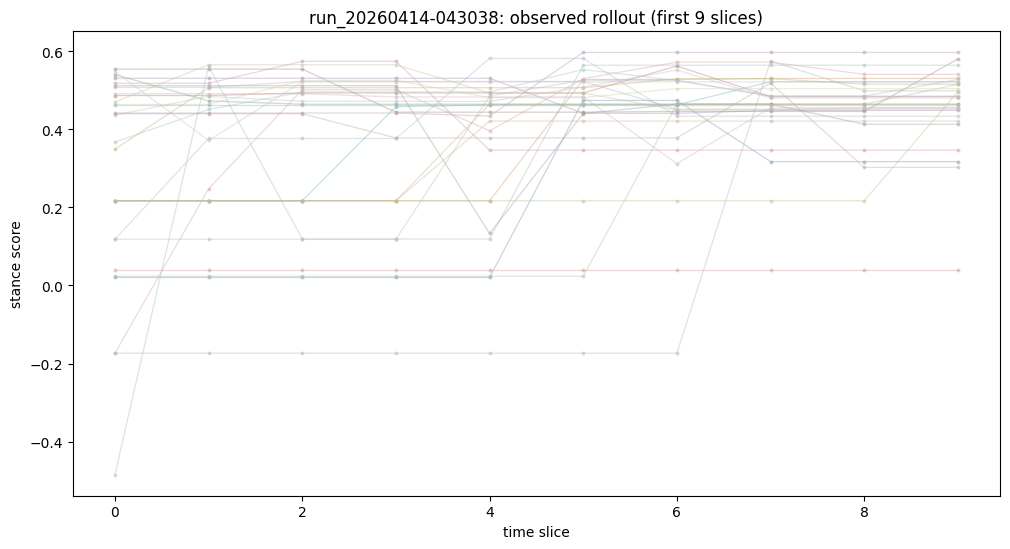

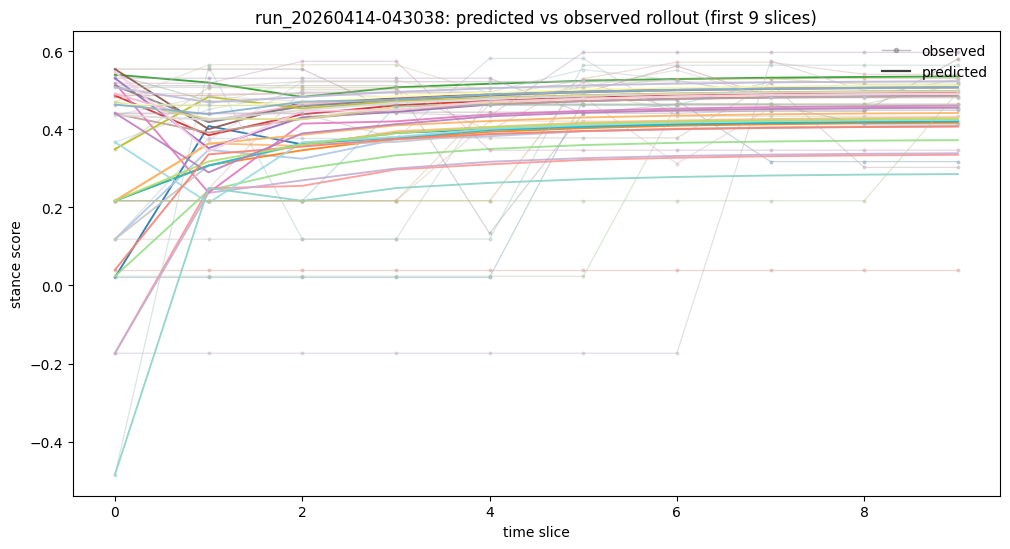

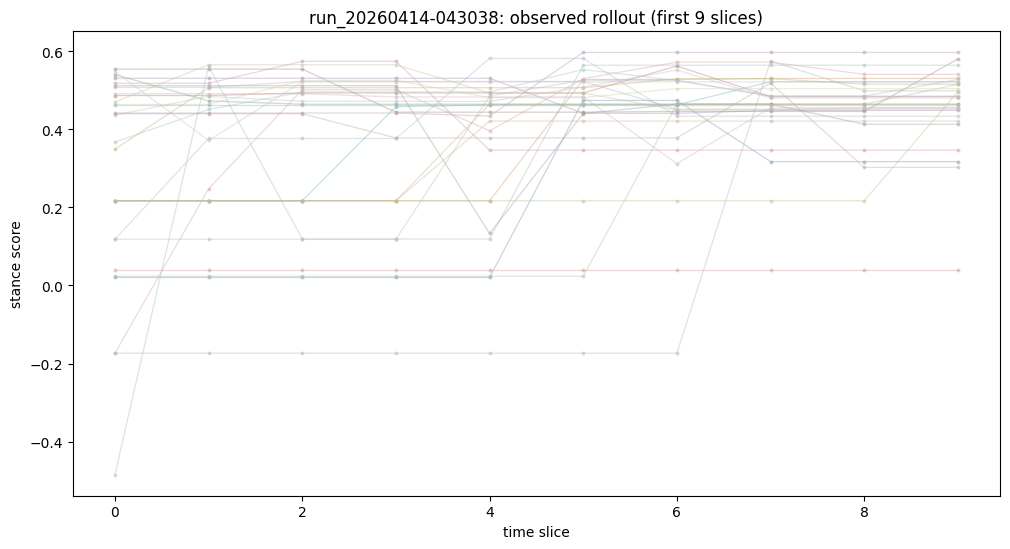

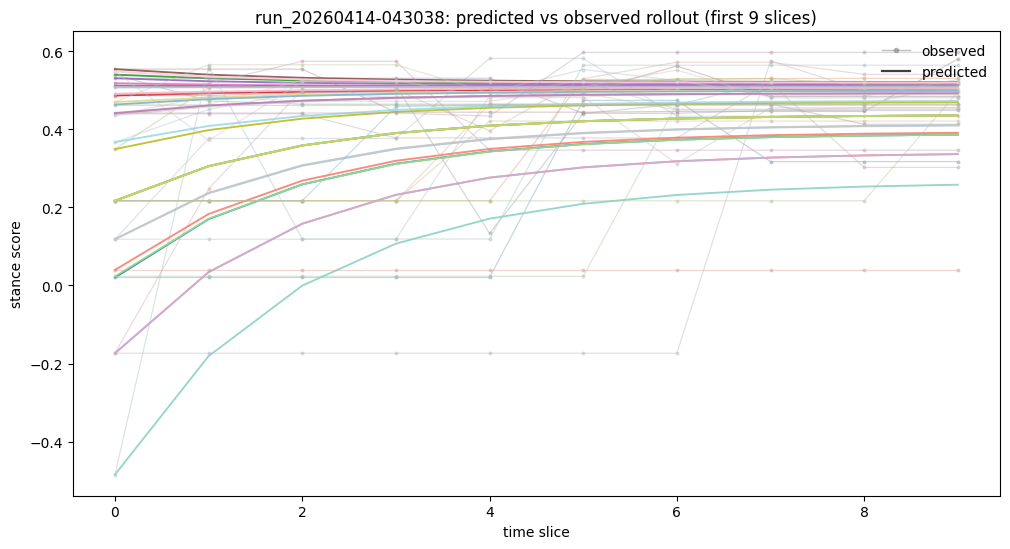

In [40]:
from plot_utils import plot_observed_trajectories, plot_predicted_vs_observed

PREDICTED_TEST_DEGROOT = {
    rn: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    )
    for rn in TEST_RUN_TRAJ.keys()
}

PREDICTED_TEST_FJ_FIXED = {
    rn: friedkin_johnsen_rollout_prediction(
        FJ_W,
        FJ_b,
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_LAMBDA1,
        FJ_LAMBDA2,
    )
    for rn in TEST_RUN_TRAJ.keys()
}

PREDICTED_TEST_FJ_JOINT = {
    rn: friedkin_johnsen_rollout_prediction(
        JOINT_W,
        JOINT_B,
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        JOINT_L1,
        JOINT_L2,
    )
    for rn in TEST_RUN_TRAJ.keys()
}

PREDICTED_TEST_FJ_ADJ = {
    rn: friedkin_johnsen_adjacency_rollout(
        fj_adj['W'],
        fj_adj['bias'],
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_LAMBDA1,
        FJ_ADJ_LAMBDA2,
    )
    for rn in TEST_RUN_TRAJ.keys()
}

# Test-only trajectory plots.
run_id = max(TEST_RUN_NAMES, key=lambda rn: np.asarray(TEST_RUN_TRAJ[rn], dtype=float).shape[0])
plot_horizon = min(
    10,
    np.asarray(TEST_RUN_TRAJ[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_DEGROOT[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_FJ_FIXED[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_FJ_JOINT[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_FJ_ADJ[run_id], dtype=float).shape[0] - 1,
)

print('Validation sample run:', run_id)
print('Plot horizon (slices):', plot_horizon)

plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_DEGROOT[run_id], GLOBAL_AGENT_IDS, plot_horizon)

plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_FJ_FIXED[run_id], GLOBAL_AGENT_IDS, plot_horizon)

plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_FJ_JOINT[run_id], GLOBAL_AGENT_IDS, plot_horizon)

plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)
plot_predicted_vs_observed(run_id, TEST_RUN_TRAJ[run_id], PREDICTED_TEST_FJ_ADJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)